## Steps ForThis Case Study

#### Step 1 : Data reading . Data Understanding . Data Cleaning Imputing missing values

#### Step 2 : Filter high value customers

#### Step 3 : Derive Target variable- Churn (Usage based churn)

#### Step 4 : Data Preparation, Derived variable, EDA, Outlier Treatment, Split into train and test sets, Perform Scaling

#### Step 5 : Good Interpretability Model for features- Logistic Regression (without PCA), High Performance Multi- Model (with PCA)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Display all columns without restrictions

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

#### Step 1 : Data reading . Data Understanding . Data Cleaning Imputing missing values

In [3]:
telecom = pd.read_csv('telecom_churn_data.csv')

In [4]:
telecom.head()

,mobile_number,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,last_date_of_month_9,arpu_6,arpu_7,arpu_8,arpu_9,onnet_mou_6,onnet_mou_7,onnet_mou_8,onnet_mou_9,offnet_mou_6,offnet_mou_7,offnet_mou_8,offnet_mou_9,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_ic_mou_9,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,roam_og_mou_9,loc_og_t2t_mou_6,loc_og_t2t_mou_7,loc_og_t2t_mou_8,loc_og_t2t_mou_9,loc_og_t2m_mou_6,loc_og_t2m_mou_7,loc_og_t2m_mou_8,loc_og_t2m_mou_9,loc_og_t2f_mou_6,loc_og_t2f_mou_7,loc_og_t2f_mou_8,loc_og_t2f_mou_9,loc_og_t2c_mou_6,loc_og_t2c_mou_7,loc_og_t2c_mou_8,loc_og_t2c_mou_9,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,loc_og_mou_9,std_og_t2t_mou_6,std_og_t2t_mou_7,std_og_t2t_mou_8,std_og_t2t_mou_9,std_og_t2m_mou_6,std_og_t2m_mou_7,std_og_t2m_mou_8,std_og_t2m_mou_9,std_og_t2f_mou_6,std_og_t2f_mou_7,std_og_t2f_mou_8,std_og_t2f_mou_9,std_og_t2c_mou_6,std_og_t2c_mou_7,std_og_t2c_mou_8,std_og_t2c_mou_9,std_og_mou_6,std_og_mou_7,std_og_mou_8,std_og_mou_9,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,isd_og_mou_9,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,spl_og_mou_9,og_others_6,og_others_7,og_others_8,og_others_9,total_og_mou_6,total_og_mou_7,total_og_mou_8,total_og_mou_9,loc_ic_t2t_mou_6,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2t_mou_9,loc_ic_t2m_mou_6,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_t2m_mou_9,loc_ic_t2f_mou_6,loc_ic_t2f_mou_7,loc_ic_t2f_mou_8,loc_ic_t2f_mou_9,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,loc_ic_mou_9,std_ic_t2t_mou_6,std_ic_t2t_mou_7,std_ic_t2t_mou_8,std_ic_t2t_mou_9,std_ic_t2m_mou_6,std_ic_t2m_mou_7,std_ic_t2m_mou_8,std_ic_t2m_mou_9,std_ic_t2f_mou_6,std_ic_t2f_mou_7,std_ic_t2f_mou_8,std_ic_t2f_mou_9,std_ic_t2o_mou_6,std_ic_t2o_mou_7,std_ic_t2o_mou_8,std_ic_t2o_mou_9,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,std_ic_mou_9,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,total_ic_mou_9,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,spl_ic_mou_9,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,isd_ic_mou_9,ic_others_6,ic_others_7,ic_others_8,ic_others_9,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_num_9,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,total_rech_amt_9,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,max_rech_amt_9,date_of_last_rech_6,date_of_last_rech_7,date_of_last_rech_8,date_of_last_rech_9,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,last_day_rch_amt_9,date_of_last_rech_data_6,date_of_last_rech_data_7,date_of_last_rech_data_8,date_of_last_rech_data_9,total_rech_data_6,total_rech_data_7,total_rech_data_8,total_rech_data_9,max_rech_data_6,max_rech_data_7,max_rech_data_8,max_rech_data_9,count_rech_2g_6,count_rech_2g_7,count_rech_2g_8,count_rech_2g_9,count_rech_3g_6,count_rech_3g_7,count_rech_3g_8,count_rech_3g_9,av_rech_amt_data_6,av_rech_amt_data_7,av_rech_amt_data_8,av_rech_amt_data_9,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_2g_mb_9,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,vol_3g_mb_9,arpu_3g_6,arpu_3g_7,arpu_3g_8,arpu_3g_9,arpu_2g_6,arpu_2g_7,arpu_2g_8,arpu_2g_9,night_pck_user_6,night_pck_user_7,night_pck_user_8,night_pck_user_9,monthly_2g_6,monthly_2g_7,monthly_2g_8,monthly_2g_9,sachet_2g_6,sachet_2g_7,sachet_2g_8,sachet_2g_9,monthly_3g_6,monthly_3g_7,monthly_3g_8,monthly_3g_9,sachet_3g_6,sachet_3g_7,sachet_3g_8,sachet_3g_9,fb_user_6,fb_user_7,fb_user_8,fb_user_9,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,sep_vbc_3g
0,7000842753,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,197.385,214.816,213.803,21.100,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.0,NaN,0.00,0.00,0.00,0.00,NaN,NaN,0.16,NaN,NaN,NaN,4.13,NaN,NaN,NaN,1.15,NaN,NaN,NaN,5.44,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.00,NaN,0.00,0.00,5.44,0.00,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,4,3,

In [5]:
telecom.shape

(99999, 226)

In [6]:
telecom.describe()

,mobile_number,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,arpu_6,arpu_7,arpu_8,arpu_9,onnet_mou_6,onnet_mou_7,onnet_mou_8,onnet_mou_9,offnet_mou_6,offnet_mou_7,offnet_mou_8,offnet_mou_9,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_ic_mou_9,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,roam_og_mou_9,loc_og_t2t_mou_6,loc_og_t2t_mou_7,loc_og_t2t_mou_8,loc_og_t2t_mou_9,loc_og_t2m_mou_6,loc_og_t2m_mou_7,loc_og_t2m_mou_8,loc_og_t2m_mou_9,loc_og_t2f_mou_6,loc_og_t2f_mou_7,loc_og_t2f_mou_8,loc_og_t2f_mou_9,loc_og_t2c_mou_6,loc_og_t2c_mou_7,loc_og_t2c_mou_8,loc_og_t2c_mou_9,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,loc_og_mou_9,std_og_t2t_mou_6,std_og_t2t_mou_7,std_og_t2t_mou_8,std_og_t2t_mou_9,std_og_t2m_mou_6,std_og_t2m_mou_7,std_og_t2m_mou_8,std_og_t2m_mou_9,std_og_t2f_mou_6,std_og_t2f_mou_7,std_og_t2f_mou_8,std_og_t2f_mou_9,std_og_t2c_mou_6,std_og_t2c_mou_7,std_og_t2c_mou_8,std_og_t2c_mou_9,std_og_mou_6,std_og_mou_7,std_og_mou_8,std_og_mou_9,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,isd_og_mou_9,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,spl_og_mou_9,og_others_6,og_others_7,og_others_8,og_others_9,total_og_mou_6,total_og_mou_7,total_og_mou_8,total_og_mou_9,loc_ic_t2t_mou_6,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2t_mou_9,loc_ic_t2m_mou_6,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_t2m_mou_9,loc_ic_t2f_mou_6,loc_ic_t2f_mou_7,loc_ic_t2f_mou_8,loc_ic_t2f_mou_9,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,loc_ic_mou_9,std_ic_t2t_mou_6,std_ic_t2t_mou_7,std_ic_t2t_mou_8,std_ic_t2t_mou_9,std_ic_t2m_mou_6,std_ic_t2m_mou_7,std_ic_t2m_mou_8,std_ic_t2m_mou_9,std_ic_t2f_mou_6,std_ic_t2f_mou_7,std_ic_t2f_mou_8,std_ic_t2f_mou_9,std_ic_t2o_mou_6,std_ic_t2o_mou_7,std_ic_t2o_mou_8,std_ic_t2o_mou_9,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,std_ic_mou_9,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,total_ic_mou_9,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,spl_ic_mou_9,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,isd_ic_mou_9,ic_others_6,ic_others_7,ic_others_8,ic_others_9,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_num_9,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,total_rech_amt_9,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,max_rech_amt_9,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,last_day_rch_amt_9,total_rech_data_6,total_rech_data_7,total_rech_data_8,total_rech_data_9,max_rech_data_6,max_rech_data_7,max_rech_data_8,max_rech_data_9,count_rech_2g_6,count_rech_2g_7,count_rech_2g_8,count_rech_2g_9,count_rech_3g_6,count_rech_3g_7,count_rech_3g_8,count_rech_3g_9,av_rech_amt_data_6,av_rech_amt_data_7,av_rech_amt_data_8,av_rech_amt_data_9,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_2g_mb_9,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,vol_3g_mb_9,arpu_3g_6,arpu_3g_7,arpu_3g_8,arpu_3g_9,arpu_2g_6,arpu_2g_7,arpu_2g_8,arpu_2g_9,night_pck_user_6,night_pck_user_7,night_pck_user_8,night_pck_user_9,monthly_2g_6,monthly_2g_7,monthly_2g_8,monthly_2g_9,sachet_2g_6,sachet_2g_7,sachet_2g_8,sachet_2g_9,monthly_3g_6,monthly_3g_7,monthly_3g_8,monthly_3g_9,sachet_3g_6,sachet_3g_7,sachet_3g_8,sachet_3g_9,fb_user_6,fb_user_7,fb_user_8,fb_user_9,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,sep_vbc_3g
count,9.999900e+04,99999.0,98981.0,98981.0,98981.0,99999.000000,99999.000000,99999.000000,99999.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.0,96140.0,94621.0,92254.0,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621

In [7]:
pd.DataFrame(telecom.columns)

,0
0,mobile_number
1,circle_id
2,loc_og_t2o_mou
3,std_og_t2o_mou
4,loc_ic_t2o_mou
5,last_date_of_month_6
6,last_date_of_month_7
7,last_date_of_month_8
8,last_date_of_month_9
9,arpu_6


In [8]:
# Checking null values

(telecom.isnull().sum()*100/telecom.shape[0]).sort_values(ascending=False)

arpu_3g_6                   74.846748
night_pck_user_6            74.846748
total_rech_data_6           74.846748
arpu_2g_6                   74.846748
max_rech_data_6             74.846748
fb_user_6                   74.846748
av_rech_amt_data_6          74.846748
date_of_last_rech_data_6    74.846748
count_rech_2g_6             74.846748
count_rech_3g_6             74.846748
date_of_last_rech_data_7    74.428744
total_rech_data_7           74.428744
fb_user_7                   74.428744
max_rech_data_7             74.428744
night_pck_user_7            74.428744
count_rech_2g_7             74.428744
av_rech_amt_data_7          74.428744
arpu_2g_7                   74.428744
count_rech_3g_7             74.428744
arpu_3g_7                   74.428744
total_rech_data_9           74.077741
count_rech_3g_9             74.077741
fb_user_9                   74.077741
max_rech_data_9             74.077741
arpu_3g_9                   74.077741
date_of_last_rech_data_9    74.077741
night_pck_us

Since there are approx 74-75% null values for average recharge amount, max recharge data and total recharge date and date of data recharge for mobile internet data is missing.

In [9]:
# Creating ID cols

id_cols = ['mobile_number', 'circle_id']
id_cols

['mobile_number', 'circle_id']

In [10]:
# Creating a seperate list for date columns

date_col = [col for col in telecom.columns if 'date' in col]
len(date_col)

12

In [11]:
# Similarly creaing a categorical columns

cat_cols =   ['night_pck_user_6',
             'night_pck_user_7',
             'night_pck_user_8',
             'night_pck_user_9',
             'fb_user_6',
             'fb_user_7',
             'fb_user_8',
             'fb_user_9'
            ]
len(cat_cols)

8

In [12]:
# Creaing Numerical cols

num_col= telecom.select_dtypes(include=['float64', 'int64']).columns

# Droping id_cols and cat_cols
num_col= num_col.drop(id_cols)
num_col= num_col.drop(cat_cols)
len(num_col)

204

In [13]:
telecom.shape

(99999, 226)

In [14]:
# Checking if any columns were missed

len(id_cols) + len(date_col) + len(num_col) + len(cat_cols) == len(telecom.columns)

True

### Missing Value

In [15]:
# the customer didn't recharge because the recharge date and the recharge value are missing
  
telecom.loc[telecom.total_rech_data_7.isnull() & telecom.date_of_last_rech_data_7.isnull(),\
          ["total_rech_data_7", "date_of_last_rech_data_7"]].head(10)

,total_rech_data_7,date_of_last_rech_data_7
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
5,NaN,NaN
6,NaN,NaN
7,NaN,NaN
10,NaN,NaN
11,NaN,NaN
12,NaN,NaN
13,NaN,NaN


In [16]:
# let's check if there are any values where total_rech_data is NA and value is present for av_rech_amt_data and vice versa
# check how many av_rech_amt_data_6 is NA

is_invalid_data_6 = telecom['av_rech_amt_data_6'] == np.nan
is_invalid_data_7 = telecom['av_rech_amt_data_7'] == np.nan
is_invalid_data_8 = telecom['av_rech_amt_data_7'] == np.nan

In [17]:
# check if any value is present for these rows for total_rech_data

print(telecom.loc[is_invalid_data_6,'total_rech_data_6'].sum())
print(telecom.loc[is_invalid_data_7,'total_rech_data_7'].sum())
print(telecom.loc[is_invalid_data_8,'total_rech_data_8'].sum())


0.0
0.0
0.0


In [18]:
# checking how many total_rech_data_6 is NA

is_invalid_data_6 = telecom['total_rech_data_6'] == np.nan 
is_invalid_data_7 = telecom['total_rech_data_7'] == np.nan 
is_invalid_data_8 = telecom['total_rech_data_8'] == np.nan

In [19]:
# check if any value is present for these rows for av_rech_amt_data_6

print(telecom.loc[is_invalid_data_6,'av_rech_amt_data_6'].sum())
print(telecom.loc[is_invalid_data_7,'av_rech_amt_data_7'].sum())
print(telecom.loc[is_invalid_data_8,'av_rech_amt_data_8'].sum())

0.0
0.0
0.0


In [20]:
# Creating column for recharge items
recharge_cols = [col for col in telecom.columns if 'rech' in col]

telecom[recharge_cols].describe()

,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_num_9,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,total_rech_amt_9,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,max_rech_amt_9,total_rech_data_6,total_rech_data_7,total_rech_data_8,total_rech_data_9,max_rech_data_6,max_rech_data_7,max_rech_data_8,max_rech_data_9,count_rech_2g_6,count_rech_2g_7,count_rech_2g_8,count_rech_2g_9,count_rech_3g_6,count_rech_3g_7,count_rech_3g_8,count_rech_3g_9,av_rech_amt_data_6,av_rech_amt_data_7,av_rech_amt_data_8,av_rech_amt_data_9
count,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,25153.000000,25571.000000,26339.000000,25922.000000,25153.000000,25571.000000,26339.000000,25922.00000,25153.000000,25571.000000,26339.000000,25922.000000,25153.000000,25571.000000,26339.000000,25922.000000,25153.000000,25571.000000,26339.000000,25922.000000
mean,7.558806,7.700367,7.212912,6.893019,327.514615,322.962970,324.157122,303.345673,104.637486,104.752398,107.728207,101.943889,2.463802,2.666419,2.651999,2.441170,126.393392,126.729459,125.717301,124.94144,1.864668,2.044699,2.016288,1.781807,0.599133,0.621720,0.635711,0.659363,192.600982,200.981292,197.526489,192.734315
std,7.078405,7.070422,7.203753,7.096261,398.019701,408.114237,416.540455,404.588583,120.614894,124.523970,126.902505,125.375109,2.789128,3.031593,3.074987,2.516339,108.477235,109.765267,109.437851,111.36376,2.570254,2.768332,2.720132,2.214701,1.274428,1.394524,1.422827,1.411513,192.646318,196.791224,191.301305,188.400286
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.500000,0.500000,1.000000
25%,3.000000,3.000000,3.000000,3.000000,109.000000,100.000000,90.000000,52.000000,30.000000,30.000000,30.000000,28.000000,1.000000,1.000000,1.000000,1.000000,25.000000,25.000000,25.000000,25.00000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,82.000000,92.000000,87.000000,69.000000
50%,6.000000,6.000000,5.000000,5.000000,230.000000,220.000000,225.000000,200.000000,110.000000,110.000000,98.000000,61.000000,1.000000,1.000000,1.000000,2.000000,145.000000,145.000000,145.000000,145.00000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,154.000000,154.000000,154.000000,164.000000
75%,9.000000,10.000000,9.000000,9.000000,437.500000,428.000000,434.500000,415.000000,120.000000,128.000000,144.000000,144.000000,3.000000,3.000000,3.000000,3.000000,177.000000,177.000000,179.000000,179.00000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,252.000000,252.000000,252.000000,252.000000
max,307.000000,138.000000,196.000000,131.000000,35190.000000,40335.000000,45320.000000,37235.000000,4010.000000,4010.000000,4449.000000,3399.000000,61.000000,54.000000,60.000000,84.000000,1555.000000,1555.000000,1555.000000,1555.00000,42.000000,48.000000,44.000000,40.000000,29.000000,35.000000,45.000000,49.000000,7546.000000,4365.000000,4076.000000,4061.000000


In [21]:
## We observe that some of the columns have minimum value of 1 while others have 0 or 0.50. So we can impute the value as 0 for people who have not recharged.

In [22]:
# Also, we observe that recharge column and recharge date columns have missing values (NAN)

telecom[recharge_cols].isnull().sum()

total_rech_num_6                0
total_rech_num_7                0
total_rech_num_8                0
total_rech_num_9                0
total_rech_amt_6                0
total_rech_amt_7                0
total_rech_amt_8                0
total_rech_amt_9                0
max_rech_amt_6                  0
max_rech_amt_7                  0
max_rech_amt_8                  0
max_rech_amt_9                  0
date_of_last_rech_6          1607
date_of_last_rech_7          1767
date_of_last_rech_8          3622
date_of_last_rech_9          4760
date_of_last_rech_data_6    74846
date_of_last_rech_data_7    74428
date_of_last_rech_data_8    73660
date_of_last_rech_data_9    74077
total_rech_data_6           74846
total_rech_data_7           74428
total_rech_data_8           73660
total_rech_data_9           74077
max_rech_data_6             74846
max_rech_data_7             74428
max_rech_data_8             73660
max_rech_data_9             74077
count_rech_2g_6             74846
count_rech_2g_

In [23]:
# creating a list for columns to be imputed with 0
impute_cols = ['total_rech_data_6', 'total_rech_data_7', 'total_rech_data_8', 'total_rech_data_9',
        'av_rech_amt_data_6', 'av_rech_amt_data_7', 'av_rech_amt_data_8', 'av_rech_amt_data_9',
        'max_rech_data_6', 'max_rech_data_7', 'max_rech_data_8', 'max_rech_data_9'
       ]
# imputing the above list with 0
telecom[impute_cols] = telecom[impute_cols].apply(lambda x: x.fillna(0))

In [24]:
# checking the missing values after imputing

telecom[impute_cols].isnull().sum()

total_rech_data_6     0
total_rech_data_7     0
total_rech_data_8     0
total_rech_data_9     0
av_rech_amt_data_6    0
av_rech_amt_data_7    0
av_rech_amt_data_8    0
av_rech_amt_data_9    0
max_rech_data_6       0
max_rech_data_7       0
max_rech_data_8       0
max_rech_data_9       0
dtype: int64

In [25]:
## Imputing categorical columns

In [26]:
telecom[cat_cols].isnull().sum()

night_pck_user_6    74846
night_pck_user_7    74428
night_pck_user_8    73660
night_pck_user_9    74077
fb_user_6           74846
fb_user_7           74428
fb_user_8           73660
fb_user_9           74077
dtype: int64

In [27]:
# replace missing values with '-1' in categorical columns

telecom[cat_cols] = telecom[cat_cols].apply(lambda x: x.fillna(-1))

In [28]:
telecom[cat_cols].isnull().sum()

night_pck_user_6    0
night_pck_user_7    0
night_pck_user_8    0
night_pck_user_9    0
fb_user_6           0
fb_user_7           0
fb_user_8           0
fb_user_9           0
dtype: int64

In [29]:
## Imputing remaining missing values in num cols with median

In [30]:
telecom[num_col].isnull().sum()

loc_og_t2o_mou         1018
std_og_t2o_mou         1018
loc_ic_t2o_mou         1018
arpu_6                    0
arpu_7                    0
arpu_8                    0
arpu_9                    0
onnet_mou_6            3937
onnet_mou_7            3859
onnet_mou_8            5378
onnet_mou_9            7745
offnet_mou_6           3937
offnet_mou_7           3859
offnet_mou_8           5378
offnet_mou_9           7745
roam_ic_mou_6          3937
roam_ic_mou_7          3859
roam_ic_mou_8          5378
roam_ic_mou_9          7745
roam_og_mou_6          3937
roam_og_mou_7          3859
roam_og_mou_8          5378
roam_og_mou_9          7745
loc_og_t2t_mou_6       3937
loc_og_t2t_mou_7       3859
loc_og_t2t_mou_8       5378
loc_og_t2t_mou_9       7745
loc_og_t2m_mou_6       3937
loc_og_t2m_mou_7       3859
loc_og_t2m_mou_8       5378
loc_og_t2m_mou_9       7745
loc_og_t2f_mou_6       3937
loc_og_t2f_mou_7       3859
loc_og_t2f_mou_8       5378
loc_og_t2f_mou_9       7745
loc_og_t2c_mou_6    

In [31]:
telecom[num_col]= telecom[num_col].apply(lambda x: x.fillna(x.median()))

In [32]:
telecom[num_col].isnull().sum()

loc_og_t2o_mou        0
std_og_t2o_mou        0
loc_ic_t2o_mou        0
arpu_6                0
arpu_7                0
arpu_8                0
arpu_9                0
onnet_mou_6           0
onnet_mou_7           0
onnet_mou_8           0
onnet_mou_9           0
offnet_mou_6          0
offnet_mou_7          0
offnet_mou_8          0
offnet_mou_9          0
roam_ic_mou_6         0
roam_ic_mou_7         0
roam_ic_mou_8         0
roam_ic_mou_9         0
roam_og_mou_6         0
roam_og_mou_7         0
roam_og_mou_8         0
roam_og_mou_9         0
loc_og_t2t_mou_6      0
loc_og_t2t_mou_7      0
loc_og_t2t_mou_8      0
loc_og_t2t_mou_9      0
loc_og_t2m_mou_6      0
loc_og_t2m_mou_7      0
loc_og_t2m_mou_8      0
loc_og_t2m_mou_9      0
loc_og_t2f_mou_6      0
loc_og_t2f_mou_7      0
loc_og_t2f_mou_8      0
loc_og_t2f_mou_9      0
loc_og_t2c_mou_6      0
loc_og_t2c_mou_7      0
loc_og_t2c_mou_8      0
loc_og_t2c_mou_9      0
loc_og_mou_6          0
loc_og_mou_7          0
loc_og_mou_8    

In [33]:
### Dropping columns having more than 70% missing values

In [34]:
telecom.drop(id_cols, axis= 1, inplace= True)

In [35]:
telecom.drop(date_col, axis= 1, inplace= True)

In [36]:
telecom.shape

(99999, 212)

In [37]:
# finding the ratio of missing values, if any

drop_missing = telecom.isnull().sum()/len(telecom) 

In [38]:
# creating a list of columns having more than 70% missing values

missing_features = drop_missing[drop_missing > 0.70].index  

In [39]:
# dropping the columns having more than 70% missing values

telecom.drop(missing_features, axis=1, inplace=True)

In [40]:
telecom.shape

(99999, 212)

In [41]:
### Extracting the High-Value Customers

In [42]:
# Calculaing high value customers based on Recharges

In [43]:
# Calculcate the total data recharge amount (gross_value) for June and July ----> num of recharge * ave recharge amount

telecom['gross_value_6'] = telecom['total_rech_data_6'] * telecom['av_rech_amt_data_6']

telecom['gross_value_7'] = telecom['total_rech_data_7'] * telecom['av_rech_amt_data_7']

In [44]:
# calculate total recharge amount for June and July --> call recharge amount + data recharge amount(gross_value)

telecom['cust_amt_data_6'] = telecom['total_rech_amt_6'] + telecom['gross_value_6']
telecom['cust_amt_data_7'] = telecom['total_rech_amt_7'] + telecom['gross_value_7']

In [45]:
# calculate average recharge done by customer in June and July

telecom['av_amt_data_6_7'] = (telecom['cust_amt_data_6'] + telecom['cust_amt_data_7'])/2

In [46]:
# Taking a look at the 70th percentile of the recharge amount data

np.percentile(telecom['av_amt_data_6_7'], 70)

478.0

In [47]:
# retain only those customers who have recharged their mobiles with more than or equal to 70th percentile amount

tel_filtered = telecom.loc[telecom['av_amt_data_6_7'] >= np.percentile(telecom['av_amt_data_6_7'], 70), :]
tel_filtered = tel_filtered.reset_index(drop=True)
tel_filtered.shape

(30001, 217)

In [48]:
#Eliminating the unwanted columns that we created to fetch high-value customers

tel_filtered = tel_filtered.drop(['gross_value_6','gross_value_7','cust_amt_data_6','cust_amt_data_7','av_amt_data_6_7'], axis=1)
tel_filtered.shape

(30001, 212)

In [49]:
## Finding the Churn rate

In [50]:
# calculating the total incoming and outgoing call minutes of usage

tel_filtered['total_calls_mou_9'] = tel_filtered['total_ic_mou_9'] + tel_filtered['total_og_mou_9']

In [51]:
# calculating the total data usage

tel_filtered['total_internet_mb_9'] = tel_filtered['vol_2g_mb_9']+ tel_filtered['vol_3g_mb_9']

In [52]:
# Creating a new feature to mark as Churn[1] or Non-Churn[0]

tel_filtered['Churn'] = tel_filtered.apply(lambda row:1 if (row.total_calls_mou_9==0 and row.total_internet_mb_9==0) 
                                             else 0, axis=1)

In [53]:
# Eliminating the columns we no longer need for further analysis

tel_filtered = tel_filtered.drop(['total_calls_mou_9','total_internet_mb_9'], axis=1)

In [54]:
# Converting Churn = 0 and 1 to string to make sure it is a Categorical Feature

tel_filtered['Churn'] = tel_filtered['Churn'].astype('category')

In [55]:
# Validating the spread of data

tel_filtered['Churn'].value_counts(normalize=True)

Churn
0    0.918636
1    0.081364
Name: proportion, dtype: float64

##### We see the Churn% is approximately 8%

In [56]:
#Deriving new columns

In [57]:

tel_filtered['arpu_diff'] = tel_filtered.arpu_8 - ((tel_filtered.arpu_6 + tel_filtered.arpu_7)/2)

tel_filtered['loc_og_mou_diff'] = tel_filtered.loc_og_mou_8 - ((tel_filtered.loc_og_mou_6 + tel_filtered.loc_og_mou_7)/2)

tel_filtered['std_og_mou_diff'] = tel_filtered.std_og_mou_8 - ((tel_filtered.std_og_mou_6 + tel_filtered.std_og_mou_7)/2)

tel_filtered['total_og_mou_diff'] = tel_filtered.total_og_mou_8 - ((tel_filtered.total_og_mou_6 + tel_filtered.total_og_mou_7)/2)

tel_filtered['loc_ic_mou_diff'] = tel_filtered.loc_ic_mou_8 - ((tel_filtered.loc_ic_mou_6 + tel_filtered.loc_ic_mou_7)/2)

tel_filtered['std_ic_mou_diff'] = tel_filtered.std_ic_mou_8 - ((tel_filtered.std_ic_mou_6 + tel_filtered.std_ic_mou_7)/2)

tel_filtered['total_ic_mou_diff'] = tel_filtered.total_ic_mou_8 - ((tel_filtered.total_ic_mou_6 + tel_filtered.total_ic_mou_7)/2)

In [58]:
tel_filtered['total_og_mou_diff'].describe()

count    30001.000000
mean       -67.437337
std        502.630069
min      -7213.410000
25%       -168.025000
50%        -14.625000
75%         67.915000
max      12768.705000
Name: total_og_mou_diff, dtype: float64

In [59]:
## Eliminating columns that are related to September(9) month

In [60]:
# we need to delete all variables relating to 9th month

tel_filtered = tel_filtered.filter(regex='[^9]$', axis=1)
tel_filtered.shape

(30001, 169)

In [61]:
# checking whether the variables relatin to 9th month are dropped or not

tel_filtered.head()

,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,loc_og_t2t_mou_6,loc_og_t2t_mou_7,loc_og_t2t_mou_8,loc_og_t2m_mou_6,loc_og_t2m_mou_7,loc_og_t2m_mou_8,loc_og_t2f_mou_6,loc_og_t2f_mou_7,loc_og_t2f_mou_8,loc_og_t2c_mou_6,loc_og_t2c_mou_7,loc_og_t2c_mou_8,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,std_og_t2t_mou_6,std_og_t2t_mou_7,std_og_t2t_mou_8,std_og_t2m_mou_6,std_og_t2m_mou_7,std_og_t2m_mou_8,std_og_t2f_mou_6,std_og_t2f_mou_7,std_og_t2f_mou_8,std_og_t2c_mou_6,std_og_t2c_mou_7,std_og_t2c_mou_8,std_og_mou_6,std_og_mou_7,std_og_mou_8,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,og_others_6,og_others_7,og_others_8,total_og_mou_6,total_og_mou_7,total_og_mou_8,loc_ic_t2t_mou_6,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2m_mou_6,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_t2f_mou_6,loc_ic_t2f_mou_7,loc_ic_t2f_mou_8,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,std_ic_t2t_mou_6,std_ic_t2t_mou_7,std_ic_t2t_mou_8,std_ic_t2m_mou_6,std_ic_t2m_mou_7,std_ic_t2m_mou_8,std_ic_t2f_mou_6,std_ic_t2f_mou_7,std_ic_t2f_mou_8,std_ic_t2o_mou_6,std_ic_t2o_mou_7,std_ic_t2o_mou_8,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,ic_others_6,ic_others_7,ic_others_8,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,total_rech_data_6,total_rech_data_7,total_rech_data_8,max_rech_data_6,max_rech_data_7,max_rech_data_8,count_rech_2g_6,count_rech_2g_7,count_rech_2g_8,count_rech_3g_6,count_rech_3g_7,count_rech_3g_8,av_rech_amt_data_6,av_rech_amt_data_7,av_rech_amt_data_8,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,arpu_3g_6,arpu_3g_7,arpu_3g_8,arpu_2g_6,arpu_2g_7,arpu_2g_8,night_pck_user_6,night_pck_user_7,night_pck_user_8,monthly_2g_6,monthly_2g_7,monthly_2g_8,sachet_2g_6,sachet_2g_7,sachet_2g_8,monthly_3g_6,monthly_3g_7,monthly_3g_8,sachet_3g_6,sachet_3g_7,sachet_3g_8,fb_user_6,fb_user_7,fb_user_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,sep_vbc_3g,Churn,arpu_diff,loc_og_mou_diff,std_og_mou_diff,total_og_mou_diff,loc_ic_mou_diff,std_ic_mou_diff,total_ic_mou_diff
0,0.0,0.0,0.0,197.385,214.816,213.803,34.31,32.33,0.00,96.31,91.735,0.00,0.00,0.00,0.00,0.00,0.00,0.00,11.91,11.61,0.00,41.03,40.43,0.00,0.00,0.00,0.00,0.0,0.0,0.00,65.11,63.685,0.00,0.00,0.00,0.00,3.95,3.635,0.00,0.00,0.00,0.00,0.0,0.0,0.0,11.64,11.09,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.00,15.69,15.74,0.16,56.49,57.08,4.13,0.88,0.93,1.15,92.16,92.55,5.44,0.00,0.00,0.00,2.03,2.04,0.00,0.00,0.00,0.00,0.0,0.0,0.0,5.89,5.96,0.00,0.00,0.00,5.44,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,4,3,2,362,252,252,252,252,252,252,252,252,1.0,1.0,1.0,252.0,252.0,252.0,0.0,0.0,0.0,1.0,1.0,1.0,252.0,252.0,252.0,30.13,1.32,5.75,83.57,150.76,109.61,212.17,212.17,212.17,212.17,212.17,212.17,0.0,0.0,0.0,0,0,0,0,0,0,1,1,1,0,0,0,1.0,1.0,1.0,968,30.40,0.00,101.20,3.58,1,7.7025,-64.3975,-11.365,0.000,-86.915,-5.925,5.440
1,0.0,0.0,0.0,1069.180,1349.850,3171.480,57.84,54.68,52.29,453.43,567.160,325.91,16.23,33.49,31.64,23.74,12.59,38.06,51.39,31.38,40.28,308.63,447.38,162.28,62.13,55.14,53.23,0.0,0.0,0.00,422.16,533.910,255.79,4.30,23.29,12.01,49.89,31.760,49.14,6.66,20.08,16.68,0.0,0.0,0.0,60.86,75.14,77.84,0.0,0.18,10.01,4.5,0.0,6.50,0.0,0.0,0.0,487.53,609.24,350.16,58.14,32.26,27.31,217.56,221.49,121.19,152.16,101.46,39.53,427.88,355.23,188.04,36.89,11.83,30.39,91.44,126.99,141.33,52.19,34.24,22.21,0.0,0.0,0.0,180.54,173.08,193.94,626.46,558.04,428.74,0.21,0.0,0.0,2.06,14.53,31.59,15.74,15.19,15.14,5,5,7,1580,790,3638,1580,790,1580,0,0,779,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.0

In [62]:
## Now we have to update the numerical and categorical columns name list so that they don't contain the variables belonging to 9th month

In [63]:
# extract all names that end with 9 for 9th month variables
names_9col = tel_filtered.filter(regex='9$', axis=1).columns

# update cat_cols
cat_cols = [col for col in cat_cols if col not in names_9col]
cat_cols.append('Churn')

# update num_cols
num_cols = [col for col in tel_filtered.columns if col not in cat_cols]

In [64]:
# checking the cat_cols list
cat_cols

['night_pck_user_6',
 'night_pck_user_7',
 'night_pck_user_8',
 'night_pck_user_9',
 'fb_user_6',
 'fb_user_7',
 'fb_user_8',
 'fb_user_9',
 'Churn']

In [65]:
cat_cols.remove('night_pck_user_9')
cat_cols.remove('fb_user_9')
cat_cols

['night_pck_user_6',
 'night_pck_user_7',
 'night_pck_user_8',
 'fb_user_6',
 'fb_user_7',
 'fb_user_8',
 'Churn']

In [66]:
# checking the num_cols list
num_cols

['loc_og_t2o_mou',
 'std_og_t2o_mou',
 'loc_ic_t2o_mou',
 'arpu_6',
 'arpu_7',
 'arpu_8',
 'onnet_mou_6',
 'onnet_mou_7',
 'onnet_mou_8',
 'offnet_mou_6',
 'offnet_mou_7',
 'offnet_mou_8',
 'roam_ic_mou_6',
 'roam_ic_mou_7',
 'roam_ic_mou_8',
 'roam_og_mou_6',
 'roam_og_mou_7',
 'roam_og_mou_8',
 'loc_og_t2t_mou_6',
 'loc_og_t2t_mou_7',
 'loc_og_t2t_mou_8',
 'loc_og_t2m_mou_6',
 'loc_og_t2m_mou_7',
 'loc_og_t2m_mou_8',
 'loc_og_t2f_mou_6',
 'loc_og_t2f_mou_7',
 'loc_og_t2f_mou_8',
 'loc_og_t2c_mou_6',
 'loc_og_t2c_mou_7',
 'loc_og_t2c_mou_8',
 'loc_og_mou_6',
 'loc_og_mou_7',
 'loc_og_mou_8',
 'std_og_t2t_mou_6',
 'std_og_t2t_mou_7',
 'std_og_t2t_mou_8',
 'std_og_t2m_mou_6',
 'std_og_t2m_mou_7',
 'std_og_t2m_mou_8',
 'std_og_t2f_mou_6',
 'std_og_t2f_mou_7',
 'std_og_t2f_mou_8',
 'std_og_t2c_mou_6',
 'std_og_t2c_mou_7',
 'std_og_t2c_mou_8',
 'std_og_mou_6',
 'std_og_mou_7',
 'std_og_mou_8',
 'isd_og_mou_6',
 'isd_og_mou_7',
 'isd_og_mou_8',
 'spl_og_mou_6',
 'spl_og_mou_7',
 'spl_og_mou

In [67]:
## Step 3 : Data Visualization

In [68]:
# Before visualizing we will change the datatypes for cat_cols and num_cols to category and int respectively for analysis

In [69]:
tel_filtered[num_cols] = tel_filtered[num_cols].apply(pd.to_numeric)
tel_filtered[cat_cols] = tel_filtered[cat_cols].apply(lambda col: col.astype('category'), axis =0)

In [70]:
tel_filtered[num_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30001 entries, 0 to 30000
Columns: 162 entries, loc_og_t2o_mou to total_ic_mou_diff
dtypes: float64(137), int64(25)
memory usage: 37.1 MB


In [71]:
tel_filtered[cat_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30001 entries, 0 to 30000
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   night_pck_user_6  30001 non-null  category
 1   night_pck_user_7  30001 non-null  category
 2   night_pck_user_8  30001 non-null  category
 3   fb_user_6         30001 non-null  category
 4   fb_user_7         30001 non-null  category
 5   fb_user_8         30001 non-null  category
 6   Churn             30001 non-null  category
dtypes: category(7)
memory usage: 206.1 KB


In [72]:
tel_filtered.isnull().sum()

loc_og_t2o_mou        0
std_og_t2o_mou        0
loc_ic_t2o_mou        0
arpu_6                0
arpu_7                0
arpu_8                0
onnet_mou_6           0
onnet_mou_7           0
onnet_mou_8           0
offnet_mou_6          0
offnet_mou_7          0
offnet_mou_8          0
roam_ic_mou_6         0
roam_ic_mou_7         0
roam_ic_mou_8         0
roam_og_mou_6         0
roam_og_mou_7         0
roam_og_mou_8         0
loc_og_t2t_mou_6      0
loc_og_t2t_mou_7      0
loc_og_t2t_mou_8      0
loc_og_t2m_mou_6      0
loc_og_t2m_mou_7      0
loc_og_t2m_mou_8      0
loc_og_t2f_mou_6      0
loc_og_t2f_mou_7      0
loc_og_t2f_mou_8      0
loc_og_t2c_mou_6      0
loc_og_t2c_mou_7      0
loc_og_t2c_mou_8      0
loc_og_mou_6          0
loc_og_mou_7          0
loc_og_mou_8          0
std_og_t2t_mou_6      0
std_og_t2t_mou_7      0
std_og_t2t_mou_8      0
std_og_t2m_mou_6      0
std_og_t2m_mou_7      0
std_og_t2m_mou_8      0
std_og_t2f_mou_6      0
std_og_t2f_mou_7      0
std_og_t2f_mou_8

In [73]:
# Univariate analysis of data

import matplotlib.pyplot as plt
import matplotlib.animation as animation
import seaborn as sns
sns.set(style="darkgrid")

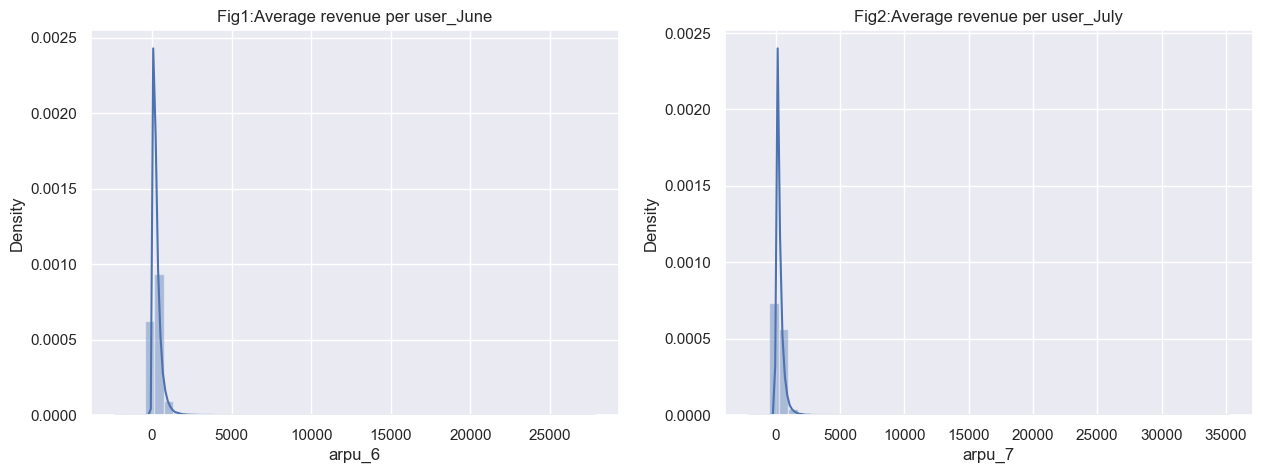

In [74]:
fig, ax = plt.subplots(1,2,figsize= [15,5])

sns.distplot(telecom.arpu_6,ax=ax[0])
sns.distplot(telecom.arpu_7,ax=ax[1])

ax[0].set_title('Fig1:Average revenue per user_June')
ax[1].set_title('Fig2:Average revenue per user_July')
plt.show()



# Plotting for Average revenue per user
#fig, ax =plt.subplots(1,2,figsize=[15,4])

#sns.distplot(data.arpu_6,ax=ax[0])
#sns.distplot(data.arpu_7,ax=ax[1])
#ax[0].set_title('Fig1:Average revenue per user_June')
#ax[1].set_title('Fig2:Average revenue per user_July')
#plt.show()

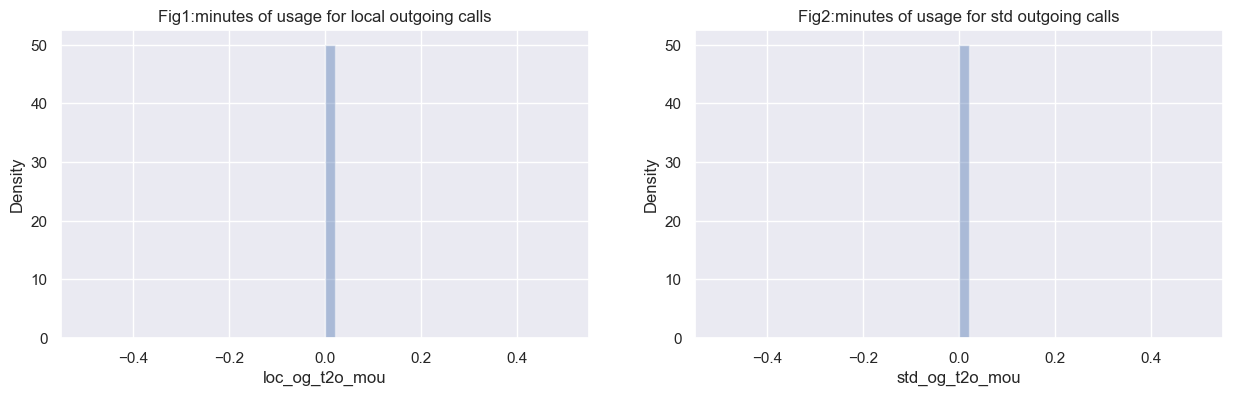

In [75]:
# Plotting for minutes of usage for local outgoing calls and std outgoing calls- Operator T to other operator fixed line

fig, ax =plt.subplots(1,2,figsize=[15,4])

sns.distplot(telecom.loc_og_t2o_mou,ax=ax[0])
sns.distplot(telecom.std_og_t2o_mou,ax=ax[1])
ax[0].set_title('Fig1:minutes of usage for local outgoing calls')
ax[1].set_title('Fig2:minutes of usage for std outgoing calls')
plt.show()



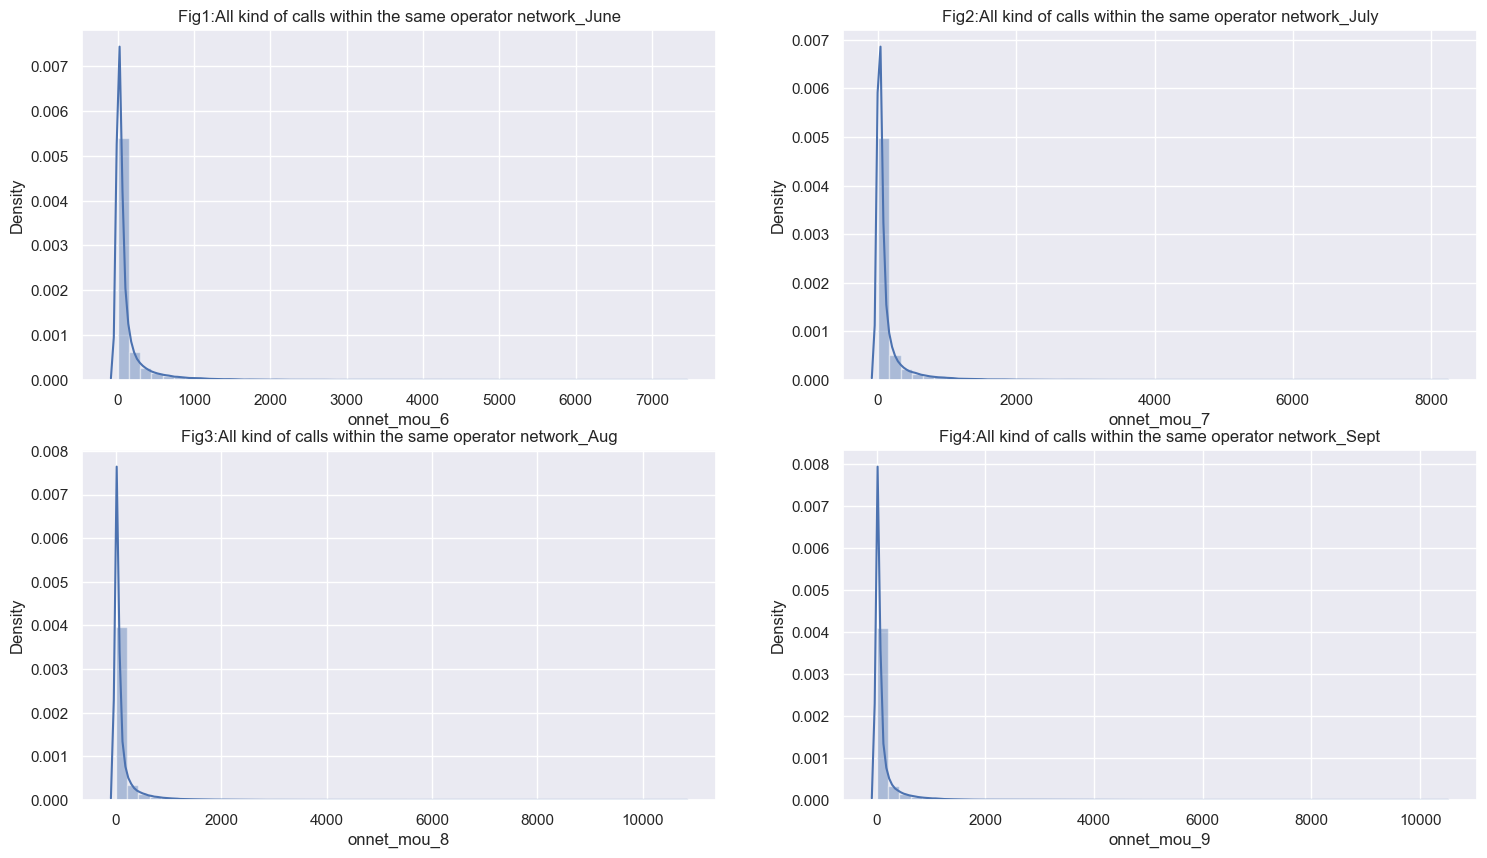

In [76]:
# Plotting for Minutes of usage for All kind of calls within the same operator network

fig, ax =plt.subplots(2,2,figsize=[18,10])

sns.distplot(telecom.onnet_mou_6,ax=ax[0,0])
sns.distplot(telecom.onnet_mou_7,ax=ax[0,1])
sns.distplot(telecom.onnet_mou_8,ax=ax[1,0])
sns.distplot(telecom.onnet_mou_9,ax=ax[1,1])

ax[0,0].set_title('Fig1:All kind of calls within the same operator network_June')
ax[0,1].set_title('Fig2:All kind of calls within the same operator network_July')
ax[1,0].set_title('Fig3:All kind of calls within the same operator network_Aug')
ax[1,1].set_title('Fig4:All kind of calls within the same operator network_Sept')
plt.show()

In [78]:
# Plotting for Prepaid service schemes called - PACKS for night

fig, ax =plt.subplots(2,2,figsize=[18,10])

sns.countplot(telecom.night_pck_user_6,ax=ax[0,0])
sns.countplot(telecom.night_pck_user_7,ax=ax[0,1])
sns.countplot(telecom.night_pck_user_8,ax=ax[1,0])
sns.countplot(telecom.night_pck_user_9,ax=ax[1,1])

ax[0,0].set_title('Fig1:Packs_for_Night_June')
ax[0,1].set_title('Fig2:Packs_for_Night_July')
ax[1,0].set_title('Fig3:Packs_for_Night_Aug')
ax[1,1].set_title('Fig4:Packs_for_Night_Sept')
plt.show()


KeyboardInterrupt



Error in callback <function _draw_all_if_interactive at 0x000001D541C7E700> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x000001D545E85C60> (for post_execute), with arguments args (),kwargs {}:



KeyboardInterrupt



In [ ]:
# Bivariate data analysis
fig, ax =plt.subplots(2,2,figsize=[18,10])

sns.countplot(tel_filtered.night_pck_user_6,ax=ax[0,0], hue= tel_filtered.Churn)
sns.countplot(tel_filtered.night_pck_user_7,ax=ax[0,1], hue= tel_filtered.Churn)
sns.countplot(tel_filtered.night_pck_user_8,ax=ax[1,0], hue= tel_filtered.Churn)
#sns.countplot(tel_filtered.night_pck_user_9,ax=ax[1,1], hue= tel_filtered.Churn)

ax[0,0].set_title('Fig1:Packs_for_Night_June Vs Chrun')
ax[0,1].set_title('Fig2:Packs_for_Night_July Vs Chrun')
ax[1,0].set_title('Fig3:Packs_for_Night_Aug Vs Chrun')
#ax[1,1].set_title('Fig4:Packs_for_Night_Sept')
plt.show()

In [79]:
# checking datatype of target variable

tel_filtered.Churn.dtype

CategoricalDtype(categories=[0, 1], ordered=False, categories_dtype=int64)

In [80]:
# Checking datatype of aon (Age on network - number of days the customer is using the operator T network)

tel_filtered.aon.dtype

dtype('int64')

In [81]:
# Plotting boxplot for Age on network and Churn variable

sns.boxplot(tel_filtered.Churn, tel_filtered.aon)
plt.show()

TypeError: boxplot() takes from 0 to 1 positional arguments but 2 were given

In [82]:
tel_filtered.head()

,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,loc_og_t2t_mou_6,loc_og_t2t_mou_7,loc_og_t2t_mou_8,loc_og_t2m_mou_6,loc_og_t2m_mou_7,loc_og_t2m_mou_8,loc_og_t2f_mou_6,loc_og_t2f_mou_7,loc_og_t2f_mou_8,loc_og_t2c_mou_6,loc_og_t2c_mou_7,loc_og_t2c_mou_8,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,std_og_t2t_mou_6,std_og_t2t_mou_7,std_og_t2t_mou_8,std_og_t2m_mou_6,std_og_t2m_mou_7,std_og_t2m_mou_8,std_og_t2f_mou_6,std_og_t2f_mou_7,std_og_t2f_mou_8,std_og_t2c_mou_6,std_og_t2c_mou_7,std_og_t2c_mou_8,std_og_mou_6,std_og_mou_7,std_og_mou_8,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,og_others_6,og_others_7,og_others_8,total_og_mou_6,total_og_mou_7,total_og_mou_8,loc_ic_t2t_mou_6,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2m_mou_6,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_t2f_mou_6,loc_ic_t2f_mou_7,loc_ic_t2f_mou_8,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,std_ic_t2t_mou_6,std_ic_t2t_mou_7,std_ic_t2t_mou_8,std_ic_t2m_mou_6,std_ic_t2m_mou_7,std_ic_t2m_mou_8,std_ic_t2f_mou_6,std_ic_t2f_mou_7,std_ic_t2f_mou_8,std_ic_t2o_mou_6,std_ic_t2o_mou_7,std_ic_t2o_mou_8,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,ic_others_6,ic_others_7,ic_others_8,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,total_rech_data_6,total_rech_data_7,total_rech_data_8,max_rech_data_6,max_rech_data_7,max_rech_data_8,count_rech_2g_6,count_rech_2g_7,count_rech_2g_8,count_rech_3g_6,count_rech_3g_7,count_rech_3g_8,av_rech_amt_data_6,av_rech_amt_data_7,av_rech_amt_data_8,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,arpu_3g_6,arpu_3g_7,arpu_3g_8,arpu_2g_6,arpu_2g_7,arpu_2g_8,night_pck_user_6,night_pck_user_7,night_pck_user_8,monthly_2g_6,monthly_2g_7,monthly_2g_8,sachet_2g_6,sachet_2g_7,sachet_2g_8,monthly_3g_6,monthly_3g_7,monthly_3g_8,sachet_3g_6,sachet_3g_7,sachet_3g_8,fb_user_6,fb_user_7,fb_user_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,sep_vbc_3g,Churn,arpu_diff,loc_og_mou_diff,std_og_mou_diff,total_og_mou_diff,loc_ic_mou_diff,std_ic_mou_diff,total_ic_mou_diff
0,0.0,0.0,0.0,197.385,214.816,213.803,34.31,32.33,0.00,96.31,91.735,0.00,0.00,0.00,0.00,0.00,0.00,0.00,11.91,11.61,0.00,41.03,40.43,0.00,0.00,0.00,0.00,0.0,0.0,0.00,65.11,63.685,0.00,0.00,0.00,0.00,3.95,3.635,0.00,0.00,0.00,0.00,0.0,0.0,0.0,11.64,11.09,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.00,15.69,15.74,0.16,56.49,57.08,4.13,0.88,0.93,1.15,92.16,92.55,5.44,0.00,0.00,0.00,2.03,2.04,0.00,0.00,0.00,0.00,0.0,0.0,0.0,5.89,5.96,0.00,0.00,0.00,5.44,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,4,3,2,362,252,252,252,252,252,252,252,252,1.0,1.0,1.0,252.0,252.0,252.0,0.0,0.0,0.0,1.0,1.0,1.0,252.0,252.0,252.0,30.13,1.32,5.75,83.57,150.76,109.61,212.17,212.17,212.17,212.17,212.17,212.17,0.0,0.0,0.0,0,0,0,0,0,0,1,1,1,0,0,0,1.0,1.0,1.0,968,30.40,0.00,101.20,3.58,1,7.7025,-64.3975,-11.365,0.000,-86.915,-5.925,5.440
1,0.0,0.0,0.0,1069.180,1349.850,3171.480,57.84,54.68,52.29,453.43,567.160,325.91,16.23,33.49,31.64,23.74,12.59,38.06,51.39,31.38,40.28,308.63,447.38,162.28,62.13,55.14,53.23,0.0,0.0,0.00,422.16,533.910,255.79,4.30,23.29,12.01,49.89,31.760,49.14,6.66,20.08,16.68,0.0,0.0,0.0,60.86,75.14,77.84,0.0,0.18,10.01,4.5,0.0,6.50,0.0,0.0,0.0,487.53,609.24,350.16,58.14,32.26,27.31,217.56,221.49,121.19,152.16,101.46,39.53,427.88,355.23,188.04,36.89,11.83,30.39,91.44,126.99,141.33,52.19,34.24,22.21,0.0,0.0,0.0,180.54,173.08,193.94,626.46,558.04,428.74,0.21,0.0,0.0,2.06,14.53,31.59,15.74,15.19,15.14,5,5,7,1580,790,3638,1580,790,1580,0,0,779,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.0

In [83]:
### Step 4: Outlier Treatment

In [84]:
def drop_outliers(i):
    list = []
    for col in num_cols:
        Q1 = i[col].quantile(.25)
        Q3 = i[col].quantile(.99)
        IQR = Q3-Q1
        i =  i[(i[col] >= (Q1-(1.5*IQR))) & (i[col] <= (Q3+(1.5*IQR)))] 
    return i   

tel_filtered = drop_outliers(tel_filtered)

In [85]:
tel_filtered.describe()

,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,loc_og_t2t_mou_6,loc_og_t2t_mou_7,loc_og_t2t_mou_8,loc_og_t2m_mou_6,loc_og_t2m_mou_7,loc_og_t2m_mou_8,loc_og_t2f_mou_6,loc_og_t2f_mou_7,loc_og_t2f_mou_8,loc_og_t2c_mou_6,loc_og_t2c_mou_7,loc_og_t2c_mou_8,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,std_og_t2t_mou_6,std_og_t2t_mou_7,std_og_t2t_mou_8,std_og_t2m_mou_6,std_og_t2m_mou_7,std_og_t2m_mou_8,std_og_t2f_mou_6,std_og_t2f_mou_7,std_og_t2f_mou_8,std_og_t2c_mou_6,std_og_t2c_mou_7,std_og_t2c_mou_8,std_og_mou_6,std_og_mou_7,std_og_mou_8,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,og_others_6,og_others_7,og_others_8,total_og_mou_6,total_og_mou_7,total_og_mou_8,loc_ic_t2t_mou_6,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2m_mou_6,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_t2f_mou_6,loc_ic_t2f_mou_7,loc_ic_t2f_mou_8,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,std_ic_t2t_mou_6,std_ic_t2t_mou_7,std_ic_t2t_mou_8,std_ic_t2m_mou_6,std_ic_t2m_mou_7,std_ic_t2m_mou_8,std_ic_t2f_mou_6,std_ic_t2f_mou_7,std_ic_t2f_mou_8,std_ic_t2o_mou_6,std_ic_t2o_mou_7,std_ic_t2o_mou_8,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,ic_others_6,ic_others_7,ic_others_8,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,total_rech_data_6,total_rech_data_7,total_rech_data_8,max_rech_data_6,max_rech_data_7,max_rech_data_8,count_rech_2g_6,count_rech_2g_7,count_rech_2g_8,count_rech_3g_6,count_rech_3g_7,count_rech_3g_8,av_rech_amt_data_6,av_rech_amt_data_7,av_rech_amt_data_8,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,arpu_3g_6,arpu_3g_7,arpu_3g_8,arpu_2g_6,arpu_2g_7,arpu_2g_8,monthly_2g_6,monthly_2g_7,monthly_2g_8,sachet_2g_6,sachet_2g_7,sachet_2g_8,monthly_3g_6,monthly_3g_7,monthly_3g_8,sachet_3g_6,sachet_3g_7,sachet_3g_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,sep_vbc_3g,arpu_diff,loc_og_mou_diff,std_og_mou_diff,total_og_mou_diff,loc_ic_mou_diff,std_ic_mou_diff,total_ic_mou_diff
count,26236.0,26236.0,26236.0,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.00000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.0,26236.0,26236.0,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.0,26236.0,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.0,26236.0,26236.0,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000000,26236.000

In [86]:
### Step 5: Modelling

In [87]:
# Converting the Churn variable to numeric to ensure the model built

tel_filtered['Churn'] = tel_filtered['Churn'].astype('int64')

In [88]:
tel_filtered['Churn'].dtype

dtype('int64')

In [89]:
## Train Test split

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [90]:
X = tel_filtered.drop('Churn', axis =1)
y= tel_filtered.Churn

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= .30, random_state = 42, stratify = y)

In [91]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(18365, 168) (7871, 168) (18365,) (7871,)


In [92]:
# Scaling the Data
X_train[num_cols].head()

,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,loc_og_t2t_mou_6,loc_og_t2t_mou_7,loc_og_t2t_mou_8,loc_og_t2m_mou_6,loc_og_t2m_mou_7,loc_og_t2m_mou_8,loc_og_t2f_mou_6,loc_og_t2f_mou_7,loc_og_t2f_mou_8,loc_og_t2c_mou_6,loc_og_t2c_mou_7,loc_og_t2c_mou_8,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,std_og_t2t_mou_6,std_og_t2t_mou_7,std_og_t2t_mou_8,std_og_t2m_mou_6,std_og_t2m_mou_7,std_og_t2m_mou_8,std_og_t2f_mou_6,std_og_t2f_mou_7,std_og_t2f_mou_8,std_og_t2c_mou_6,std_og_t2c_mou_7,std_og_t2c_mou_8,std_og_mou_6,std_og_mou_7,std_og_mou_8,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,og_others_6,og_others_7,og_others_8,total_og_mou_6,total_og_mou_7,total_og_mou_8,loc_ic_t2t_mou_6,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2m_mou_6,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_t2f_mou_6,loc_ic_t2f_mou_7,loc_ic_t2f_mou_8,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,std_ic_t2t_mou_6,std_ic_t2t_mou_7,std_ic_t2t_mou_8,std_ic_t2m_mou_6,std_ic_t2m_mou_7,std_ic_t2m_mou_8,std_ic_t2f_mou_6,std_ic_t2f_mou_7,std_ic_t2f_mou_8,std_ic_t2o_mou_6,std_ic_t2o_mou_7,std_ic_t2o_mou_8,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,ic_others_6,ic_others_7,ic_others_8,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,total_rech_data_6,total_rech_data_7,total_rech_data_8,max_rech_data_6,max_rech_data_7,max_rech_data_8,count_rech_2g_6,count_rech_2g_7,count_rech_2g_8,count_rech_3g_6,count_rech_3g_7,count_rech_3g_8,av_rech_amt_data_6,av_rech_amt_data_7,av_rech_amt_data_8,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,arpu_3g_6,arpu_3g_7,arpu_3g_8,arpu_2g_6,arpu_2g_7,arpu_2g_8,monthly_2g_6,monthly_2g_7,monthly_2g_8,sachet_2g_6,sachet_2g_7,sachet_2g_8,monthly_3g_6,monthly_3g_7,monthly_3g_8,sachet_3g_6,sachet_3g_7,sachet_3g_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,sep_vbc_3g,arpu_diff,loc_og_mou_diff,std_og_mou_diff,total_og_mou_diff,loc_ic_mou_diff,std_ic_mou_diff,total_ic_mou_diff
1878,0.0,0.0,0.0,373.947,472.313,42.541,99.03,190.98,5.64,332.26,293.51,36.56,0.00,0.0,0.00,0.00,0.0,0.00,9.38,84.18,5.33,74.24,138.36,14.59,0.00,0.00,0.00,0.00,0.00,0.00,83.63,222.54,19.93,89.64,106.79,0.31,257.68,155.14,20.63,0.0,0.00,0.0,0.0,0.0,0.0,347.33,261.94,20.94,0.0,0.0,0.0,0.33,0.00,1.33,0.00,0.0,0.0,431.29,484.49,42.21,11.23,38.36,18.53,31.78,53.29,26.88,0.00,0.51,0.00,43.01,92.18,45.41,0.00,0.81,0.00,7.84,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,7.84,0.81,0.00,51.49,92.99,45.76,0.63,0.00,0.25,0.00,0.00,0.00,0.00,0.00,0.10,7,15,2,480,493,30,110,110,30,110,110,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.48,0.42,0.88,10.83,8.81,9.27,0,0,0,0,0,0,0,0,0,0,0,0,430,0.0,0.00,0.00,0.0,-380.5890,-133.155,-283.695,-415.680,-22.185,-4.325,-26.480
19962,0.0,0.0,0.0,563.795,610.960,456.463,185.79,194.73,163.39,110.16,124.83,114.81,41.18,0.0,28.96,51.81,0.0,46.09,16.06,21.16,15.58,27.91,42.01,42.26,0.70,0.00,0.44,6.05,17.44,18.56,44.68,63.18,58.29,138.18,173.56,118.06,60.78,50.79,29.83,0.0,1.86,0.0,0.0,0.0,0.0,198.96,226.23,147.89,0.0,0.0,0.0,8.31,31.18,25.91,0.00,0.0,0.0,251.96,320.59,232.11,18.51,59.11,27.26,26.84,63.26,35.48,0.00,0.00,3.19,45.36,122.38,65.94,26.36,29.84,17.06,16.84,51.21,21.34,5.06,2.08,0.00,0.0,0.0,0.0,48.28,83.14,38.41,93.64,205.53,104.36,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,7,5,9,579,1379,678,154,1050,500,110,67,0,1.0,2.0,7.0,154.0,152.0,152.0,1.0,1.0,6.0,0.0,1.0,1.0,154.0,304.0,419.0,499.21,198.2,9.62,2.15,626.44,170.32,0.00,123.61,139.54,0.00,63.96,86.06,1,0,0,0,1,6,0,0,0,0,1,1,2666,138.8,791.02,5.72,0.0,-130.9145,4.360,-64.705,-54.165

In [93]:
scaler = MinMaxScaler()
#scaled = scaler.fit_transform(X_train)
scaled = scaler.fit_transform(X_train[num_cols])
scaled

array([[0.        , 0.        , 0.        , ..., 0.40344841, 0.38567953,
        0.42607008],
       [0.        , 0.        , 0.        , ..., 0.405804  , 0.35052106,
        0.41604518],
       [0.        , 0.        , 0.        , ..., 0.24443903, 0.39206084,
        0.27470459],
       ...,
       [0.        , 0.        , 0.        , ..., 0.43455551, 0.38636051,
        0.4611425 ],
       [0.        , 0.        , 0.        , ..., 0.41558068, 0.38529695,
        0.44232009],
       [0.        , 0.        , 0.        , ..., 0.43518662, 0.36648966,
        0.45003998]])

In [94]:
# Import Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

logreg = LogisticRegression()

In [103]:
rfe = RFE(estimator=logreg, n_features_to_select=12)
rfe = rfe.fit(X_train, y_train)

In [104]:
# Checking the features that have been selected by RFE

list(zip(X_train.columns, rfe.support_, rfe.ranking_))

[('loc_og_t2o_mou', False, 157),
 ('std_og_t2o_mou', False, 156),
 ('loc_ic_t2o_mou', False, 155),
 ('arpu_6', False, 94),
 ('arpu_7', False, 93),
 ('arpu_8', False, 60),
 ('onnet_mou_6', False, 27),
 ('onnet_mou_7', False, 86),
 ('onnet_mou_8', True, 1),
 ('offnet_mou_6', False, 28),
 ('offnet_mou_7', False, 83),
 ('offnet_mou_8', False, 2),
 ('roam_ic_mou_6', False, 76),
 ('roam_ic_mou_7', False, 30),
 ('roam_ic_mou_8', False, 126),
 ('roam_og_mou_6', False, 29),
 ('roam_og_mou_7', False, 87),
 ('roam_og_mou_8', False, 3),
 ('loc_og_t2t_mou_6', False, 64),
 ('loc_og_t2t_mou_7', False, 85),
 ('loc_og_t2t_mou_8', False, 110),
 ('loc_og_t2m_mou_6', False, 52),
 ('loc_og_t2m_mou_7', False, 136),
 ('loc_og_t2m_mou_8', False, 78),
 ('loc_og_t2f_mou_6', False, 96),
 ('loc_og_t2f_mou_7', False, 50),
 ('loc_og_t2f_mou_8', False, 15),
 ('loc_og_t2c_mou_6', False, 4),
 ('loc_og_t2c_mou_7', False, 74),
 ('loc_og_t2c_mou_8', False, 112),
 ('loc_og_mou_6', False, 53),
 ('loc_og_mou_7', False, 57),

In [105]:
# Saving the columns selected by RFE in col

col = X_train.columns[rfe.support_]

In [106]:
# saving the columns selected by RFE in X_train

X_train_log_rfe = X_train[col]
X_train_log_rfe.head()

,onnet_mou_8,total_og_mou_8,total_rech_num_7,total_rech_num_8,total_rech_data_6,total_rech_data_7,total_rech_data_8,count_rech_2g_6,count_rech_2g_8,sachet_2g_6,sachet_2g_7,sep_vbc_3g
1878,5.64,42.21,15,2,0.0,0.0,0.0,1.0,1.0,0,0,0.0
19962,163.39,232.11,5,9,1.0,2.0,7.0,1.0,6.0,0,1,0.0
11146,37.64,295.36,13,7,0.0,0.0,0.0,1.0,1.0,0,0,0.0
18553,66.74,170.44,4,3,2.0,0.0,0.0,1.0,1.0,0,0,0.0
826,1636.74,2067.44,39,41,0.0,0.0,0.0,1.0,1.0,0,0,0.0


In [107]:
X_train_log_rfe.shape

(18365, 12)

In [108]:
# Importing statsmodel
import statsmodels.api as sm

In [109]:
X_train_sm = sm.add_constant(X_train_log_rfe)
logm1 = sm.GLM(y_train, X_train_sm, family = sm.families.Binomial())
res= logm1.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  Churn   No. Observations:                18365
Model:                            GLM   Df Residuals:                    18352
Model Family:                Binomial   Df Model:                           12
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3803.6
Date:                Mon, 20 Apr 2026   Deviance:                       7607.2
Time:                        20:51:32   Pearson chi2:                 1.12e+07
No. Iterations:                    11   Pseudo R-squ. (CS):             0.1192
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.6064      0.097    -16.540      0.000      -1.797      -1.416
onnet_mou_8           0.0026      0.000     11.425      0.000       0.002       0.003
total_og_mou_8       -0.0033      0.000    -17.404      0.000      -0.004      -0.003
total_rech_num_7      0.0615      0.005     12.331      0.000       0.052       0.071
total_rech_num_8     -0.1058      0.009    -12.129      0.000      -0.123      -0.089
total_rech_data_6     0.0974      0.042      2.296      0.022       0.014       0.181
total_rech_data_7    -0.2052      0.050     -4.112      0.000      -0.303      -0.107
total_rech_data_8    -0.9683      0.056    -17.341      0.000      -1.078      -0.859
count_rech_2g_6      -0.2619      0.070     -3.749      0.000      -0.399      -0.125
count_rech_2g_8       0.7982      0.069     11.576      0.000       0.663       0.933
sachet_2g_6           0.1902      0.083      2.291      0.022       0.028       0.353
sachet_2g_7           0.1622      0.054      3.000      0.003       0.056       0.268
sep_vbc_3g           -0.1396      0.032     -4.408      0.000      -0.202      -0.078
=====================================================================================
"""

In [110]:
# Checking VIF

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [111]:
# making VIF dataframe for the variables

vif = pd.DataFrame()
vif['Features'] = X_train_log_rfe.columns
vif['VIF'] = [variance_inflation_factor(X_train_log_rfe.values, i) for i in range (X_train_log_rfe.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = 'VIF', ascending = False)
vif

,Features,VIF
9,sachet_2g_6,34.73
7,count_rech_2g_6,30.68
5,total_rech_data_7,20.47
10,sachet_2g_7,19.34
4,total_rech_data_6,16.81
8,count_rech_2g_8,14.36
6,total_rech_data_8,12.99
3,total_rech_num_8,7.29
2,total_rech_num_7,6.83
1,total_og_mou_8,4.23


In [112]:
# Dropping count_rech_2g_6 based on high VIF

X_train_log_rfe.drop('count_rech_2g_6', axis= 1, inplace = True)

In [113]:
X_train_sm = sm.add_constant(X_train_log_rfe)
logm2 = sm.GLM(y_train, X_train_sm, family = sm.families.Binomial())
res= logm2.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  Churn   No. Observations:                18365
Model:                            GLM   Df Residuals:                    18353
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3810.7
Date:                Mon, 20 Apr 2026   Deviance:                       7621.5
Time:                        20:51:40   Pearson chi2:                 1.20e+07
No. Iterations:                    11   Pseudo R-squ. (CS):             0.1185
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.7718      0.087    -20.301      0.000      -1.943      -1.601
onnet_mou_8           0.0026      0.000     11.448      0.000       0.002       0.003
total_og_mou_8       -0.0034      0.000    -17.536      0.000      -0.004      -0.003
total_rech_num_7      0.0609      0.005     12.206      0.000       0.051       0.071
total_rech_num_8     -0.1064      0.009    -12.178      0.000      -0.123      -0.089
total_rech_data_6     0.1147      0.042      2.748      0.006       0.033       0.197
total_rech_data_7    -0.1973      0.050     -3.957      0.000      -0.295      -0.100
total_rech_data_8    -0.9388      0.056    -16.826      0.000      -1.048      -0.829
count_rech_2g_8       0.7578      0.069     11.019      0.000       0.623       0.893
sachet_2g_6          -0.0669      0.045     -1.485      0.138      -0.155       0.021
sachet_2g_7           0.1631      0.054      3.020      0.003       0.057       0.269
sep_vbc_3g           -0.1395      0.032     -4.407      0.000      -0.202      -0.077
=====================================================================================
"""

In [114]:
# making VIF dataframe for the variables

vif = pd.DataFrame()
vif['Features'] = X_train_log_rfe.columns
vif['VIF'] = [variance_inflation_factor(X_train_log_rfe.values, i) for i in range (X_train_log_rfe.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = 'VIF', ascending = False)
vif

,Features,VIF
5,total_rech_data_7,19.81
9,sachet_2g_7,18.40
4,total_rech_data_6,16.39
8,sachet_2g_6,15.89
7,count_rech_2g_8,11.39
6,total_rech_data_8,11.12
3,total_rech_num_8,7.29
2,total_rech_num_7,6.58
1,total_og_mou_8,4.08
0,onnet_mou_8,2.82


In [115]:
# Dropping total_rech_data_8 based on high VIF

X_train_log_rfe.drop('total_rech_data_8', axis= 1, inplace = True)

In [116]:
X_train_sm = sm.add_constant(X_train_log_rfe)
logm3 = sm.GLM(y_train, X_train_sm, family = sm.families.Binomial())
res= logm3.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  Churn   No. Observations:                18365
Model:                            GLM   Df Residuals:                    18354
Model Family:                Binomial   Df Model:                           10
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3990.2
Date:                Mon, 20 Apr 2026   Deviance:                       7980.3
Time:                        20:51:47   Pearson chi2:                 1.66e+07
No. Iterations:                    11   Pseudo R-squ. (CS):             0.1011
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.0408      0.070    -14.776      0.000      -1.179      -0.903
onnet_mou_8           0.0028      0.000     11.983      0.000       0.002       0.003
total_og_mou_8       -0.0033      0.000    -16.836      0.000      -0.004      -0.003
total_rech_num_7      0.0803      0.005     16.133      0.000       0.071       0.090
total_rech_num_8     -0.1482      0.009    -16.104      0.000      -0.166      -0.130
total_rech_data_6    -0.0391      0.042     -0.927      0.354      -0.122       0.044
total_rech_data_7    -0.5579      0.051    -11.042      0.000      -0.657      -0.459
count_rech_2g_8      -0.1431      0.033     -4.283      0.000      -0.209      -0.078
sachet_2g_6           0.0843      0.045      1.870      0.062      -0.004       0.173
sachet_2g_7           0.4670      0.055      8.474      0.000       0.359       0.575
sep_vbc_3g           -0.1610      0.034     -4.798      0.000      -0.227      -0.095
=====================================================================================
"""

In [117]:
# making VIF dataframe for the variables

vif = pd.DataFrame()
vif['Features'] = X_train_log_rfe.columns
vif['VIF'] = [variance_inflation_factor(X_train_log_rfe.values, i) for i in range (X_train_log_rfe.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = 'VIF', ascending = False)
vif

,Features,VIF
5,total_rech_data_7,17.26
8,sachet_2g_7,17.23
4,total_rech_data_6,15.97
7,sachet_2g_6,15.53
3,total_rech_num_8,6.87
2,total_rech_num_7,5.89
1,total_og_mou_8,4.00
6,count_rech_2g_8,3.39
0,onnet_mou_8,2.82
9,sep_vbc_3g,1.05


In [118]:
# Dropping total_rech_data_8 based on high P value

X_train_log_rfe.drop('count_rech_2g_8', axis= 1, inplace = True)

In [119]:
X_train_sm = sm.add_constant(X_train_log_rfe)
logm4 = sm.GLM(y_train, X_train_sm, family = sm.families.Binomial())
res= logm4.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  Churn   No. Observations:                18365
Model:                            GLM   Df Residuals:                    18355
Model Family:                Binomial   Df Model:                            9
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4000.3
Date:                Mon, 20 Apr 2026   Deviance:                       8000.6
Time:                        20:51:51   Pearson chi2:                 1.65e+07
No. Iterations:                    11   Pseudo R-squ. (CS):             0.1001
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.1633      0.064    -18.122      0.000      -1.289      -1.038
onnet_mou_8           0.0028      0.000     11.983      0.000       0.002       0.003
total_og_mou_8       -0.0032      0.000    -16.566      0.000      -0.004      -0.003
total_rech_num_7      0.0848      0.005     17.259      0.000       0.075       0.094
total_rech_num_8     -0.1629      0.009    -18.501      0.000      -0.180      -0.146
total_rech_data_6    -0.0319      0.042     -0.760      0.447      -0.114       0.050
total_rech_data_7    -0.5311      0.050    -10.646      0.000      -0.629      -0.433
sachet_2g_6           0.0696      0.045      1.551      0.121      -0.018       0.158
sachet_2g_7           0.4043      0.053      7.615      0.000       0.300       0.508
sep_vbc_3g           -0.1602      0.033     -4.801      0.000      -0.226      -0.095
=====================================================================================
"""

In [120]:
# making VIF dataframe for the variables

vif = pd.DataFrame()
vif['Features'] = X_train_log_rfe.columns
vif['VIF'] = [variance_inflation_factor(X_train_log_rfe.values, i) for i in range (X_train_log_rfe.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = 'VIF', ascending = False)
vif

,Features,VIF
5,total_rech_data_7,17.25
7,sachet_2g_7,16.39
4,total_rech_data_6,15.90
6,sachet_2g_6,15.53
3,total_rech_num_8,6.10
2,total_rech_num_7,5.77
1,total_og_mou_8,4.00
0,onnet_mou_8,2.82
8,sep_vbc_3g,1.05


In [121]:
# Dropping total_rech_data_8 based on high VIF value

X_train_log_rfe.drop('total_rech_num_8', axis= 1, inplace = True)

In [122]:
X_train_sm = sm.add_constant(X_train_log_rfe)
logm5 = sm.GLM(y_train, X_train_sm, family = sm.families.Binomial())
res= logm5.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  Churn   No. Observations:                18365
Model:                            GLM   Df Residuals:                    18356
Model Family:                Binomial   Df Model:                            8
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4228.1
Date:                Mon, 20 Apr 2026   Deviance:                       8456.3
Time:                        20:51:54   Pearson chi2:                 2.54e+08
No. Iterations:                    11   Pseudo R-squ. (CS):            0.07748
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.2312      0.061    -20.212      0.000      -1.351      -1.112
onnet_mou_8           0.0031      0.000     13.007      0.000       0.003       0.004
total_og_mou_8       -0.0044      0.000    -23.053      0.000      -0.005      -0.004
total_rech_num_7      0.0233      0.004      6.652      0.000       0.016       0.030
total_rech_data_6    -0.0777      0.042     -1.849      0.064      -0.160       0.005
total_rech_data_7    -0.5356      0.050    -10.774      0.000      -0.633      -0.438
sachet_2g_6           0.0764      0.045      1.708      0.088      -0.011       0.164
sachet_2g_7           0.3749      0.053      7.121      0.000       0.272       0.478
sep_vbc_3g           -0.1712      0.034     -4.968      0.000      -0.239      -0.104
=====================================================================================
"""

In [123]:
# making VIF dataframe for the variables

vif = pd.DataFrame()
vif['Features'] = X_train_log_rfe.columns
vif['VIF'] = [variance_inflation_factor(X_train_log_rfe.values, i) for i in range (X_train_log_rfe.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = 'VIF', ascending = False)
vif

,Features,VIF
4,total_rech_data_7,17.23
6,sachet_2g_7,16.37
3,total_rech_data_6,15.87
5,sachet_2g_6,15.53
1,total_og_mou_8,3.72
0,onnet_mou_8,2.82
2,total_rech_num_7,2.46
7,sep_vbc_3g,1.05


In [124]:
# Dropping total_rech_data_8 based on high VIF value

X_train_log_rfe.drop('total_rech_data_6', axis= 1, inplace = True)

In [125]:
X_train_sm = sm.add_constant(X_train_log_rfe)
logm6 = sm.GLM(y_train, X_train_sm, family = sm.families.Binomial())
res= logm6.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  Churn   No. Observations:                18365
Model:                            GLM   Df Residuals:                    18357
Model Family:                Binomial   Df Model:                            7
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4229.9
Date:                Mon, 20 Apr 2026   Deviance:                       8459.8
Time:                        20:51:57   Pearson chi2:                 2.35e+08
No. Iterations:                    11   Pseudo R-squ. (CS):            0.07731
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.2731      0.057    -22.515      0.000      -1.384      -1.162
onnet_mou_8           0.0031      0.000     13.007      0.000       0.003       0.004
total_og_mou_8       -0.0044      0.000    -22.971      0.000      -0.005      -0.004
total_rech_num_7      0.0244      0.003      7.062      0.000       0.018       0.031
total_rech_data_7    -0.5741      0.046    -12.608      0.000      -0.663      -0.485
sachet_2g_6          -0.0015      0.015     -0.095      0.925      -0.032       0.029
sachet_2g_7           0.4154      0.048      8.614      0.000       0.321       0.510
sep_vbc_3g           -0.1719      0.034     -4.983      0.000      -0.240      -0.104
=====================================================================================
"""

In [126]:
# making VIF dataframe for the variables

vif = pd.DataFrame()
vif['Features'] = X_train_log_rfe.columns
vif['VIF'] = [variance_inflation_factor(X_train_log_rfe.values, i) for i in range (X_train_log_rfe.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = 'VIF', ascending = False)
vif

,Features,VIF
5,sachet_2g_7,10.84
3,total_rech_data_7,10.70
1,total_og_mou_8,3.71
0,onnet_mou_8,2.82
2,total_rech_num_7,2.45
4,sachet_2g_6,2.24
6,sep_vbc_3g,1.05


In [127]:
X_train_log_rfe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18365 entries, 1878 to 4037
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   onnet_mou_8        18365 non-null  float64
 1   total_og_mou_8     18365 non-null  float64
 2   total_rech_num_7   18365 non-null  int64  
 3   total_rech_data_7  18365 non-null  float64
 4   sachet_2g_6        18365 non-null  int64  
 5   sachet_2g_7        18365 non-null  int64  
 6   sep_vbc_3g         18365 non-null  float64
dtypes: float64(4), int64(3)
memory usage: 1.1 MB


In [128]:
# Predecting the probabilites on train set

y_train_pred_sm = res.predict(X_train_sm)
y_train_pred_sm[:10]

1878     0.254272
19962    0.082928
11146    0.105214
18553    0.151791
826      0.012253
25452    0.204097
7741     0.022347
4395     0.084852
7597     0.101100
19538    0.088341
dtype: float64

In [129]:
# Reshaping into array

y_train_pred_sm = y_train_pred_sm.values.reshape(-1)
y_train_pred_sm[:10]

array([0.25427166, 0.0829275 , 0.10521372, 0.1517907 , 0.01225346,
       0.20409748, 0.0223474 , 0.0848524 , 0.10110001, 0.08834118])

In [130]:
# Data frame with given convertion rate and probablity of predicted ones

y_train_pred_sm_final = pd.DataFrame({'Churn':y_train.values, 'Churn_Prob':y_train_pred_sm})
y_train_pred_sm_final.head()

,Churn,Churn_Prob
0,0,0.254272
1,0,0.082928
2,0,0.105214
3,0,0.151791
4,0,0.012253


In [131]:
# Substituting 0 or 1 with the cut off as 0.5

y_train_pred_sm_final['Predicted_Logistic_Reg'] = y_train_pred_sm_final['Churn_Prob'].map(lambda x: 1 if x > 0.5 else 0)
y_train_pred_sm_final.head()

,Churn,Churn_Prob,Predicted_Logistic_Reg
0,0,0.254272,0
1,0,0.082928,0
2,0,0.105214,0
3,0,0.151791,0
4,0,0.012253,0


In [132]:
### Starting Model Evaluation with the cut off as 0.5

In [133]:
# Importing metrics

from sklearn import metrics

In [134]:
# Creating cofusion matrix

confusion = metrics.confusion_matrix(y_train_pred_sm_final.Churn, y_train_pred_sm_final.Predicted_Logistic_Reg )
confusion

array([[16948,     9],
       [ 1400,     8]], dtype=int64)

In [135]:
#                    # Predicted   # Predicted
#                    not_churn      churn 
#Actual not_churn    16946            11
# churn              1392             16

In [136]:
# Checking overall accurarcy

metrics.accuracy_score(y_train_pred_sm_final.Churn, y_train_pred_sm_final.Predicted_Logistic_Reg)

0.923277974407841

In [137]:
 #Value of True Positive
TP= confusion[1,1]

# True Negative
TN= confusion[0,0]

#False positive
FP= confusion[0,1]

#False negative
FN= confusion[1,0]

In [138]:
# Calculating sensitivity

TP/(TP+FN)

0.005681818181818182

In [139]:
# Calculating specificity
TN/(TN+FP)

0.9994692457392227

In [140]:
# ROC function
def draw_roc( actual, probs ):
    fpr, tpr, thresholds = metrics.roc_curve( actual, probs,
                                              drop_intermediate = False )
    auc_score = metrics.roc_auc_score( actual, probs )
    plt.figure(figsize=(5, 5))
    plt.plot( fpr, tpr, label='ROC curve (area = %0.2f)' % auc_score )
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic example')
    plt.legend(loc="lower right")
    plt.show()

    return None

In [141]:
fpr, tpr, thresholds = metrics.roc_curve( y_train_pred_sm_final.Churn, y_train_pred_sm_final.Churn_Prob, drop_intermediate = False )

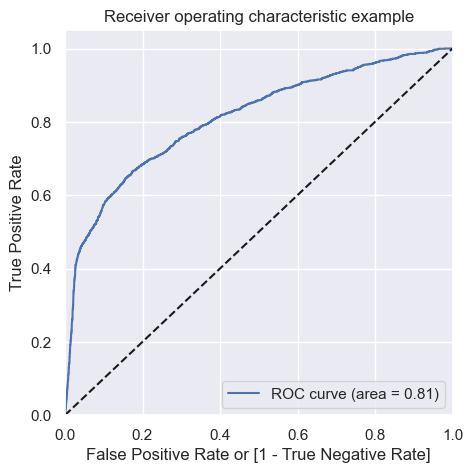

In [142]:
# Call the ROC function
draw_roc(y_train_pred_sm_final.Churn, y_train_pred_sm_final.Churn_Prob)

In [143]:
## The area under ROC curve is 0.86 which is a good value.

In [144]:
# Creating columns with different probability cutoffs 

numbers = [float(x)/10 for x in range(10)]
for i in numbers:
    y_train_pred_sm_final[i]= y_train_pred_sm_final.Churn_Prob.map(lambda x: 1 if x > i else 0)
y_train_pred_sm_final.head()

,Churn,Churn_Prob,Predicted_Logistic_Reg,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
0,0,0.254272,0,1,1,1,0,0,0,0,0,0,0
1,0,0.082928,0,1,0,0,0,0,0,0,0,0,0
2,0,0.105214,0,1,1,0,0,0,0,0,0,0,0
3,0,0.151791,0,1,1,0,0,0,0,0,0,0,0
4,0,0.012253,0,1,0,0,0,0,0,0,0,0,0


In [145]:
# Creating a dataframe to see the values of accuracy, sensitivity, and specificity at different values of probabiity cutoffs
cutoff_df = pd.DataFrame( columns = ['prob','accuracy','sensi','speci'])

# Making confusing matrix to find values of sensitivity, accurace and specificity for each level of probablity
from sklearn.metrics import confusion_matrix

num = [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for i in num:
    cm1 = metrics.confusion_matrix(y_train_pred_sm_final.Churn, y_train_pred_sm_final[i] )
    total1=sum(sum(cm1))
    accuracy = (cm1[0,0]+cm1[1,1])/total1
    
    speci = cm1[0,0]/(cm1[0,0]+cm1[0,1])
    sensi = cm1[1,1]/(cm1[1,0]+cm1[1,1])
    cutoff_df.loc[i] =[ i ,accuracy,sensi,speci]
cutoff_df

,prob,accuracy,sensi,speci
0.0,0.0,0.076668,1.000000,0.000000
0.1,0.1,0.735911,0.720881,0.737159
0.2,0.2,0.911408,0.476562,0.947514
0.3,0.3,0.923605,0.087358,0.993041
0.4,0.4,0.923060,0.016335,0.998349
0.5,0.5,0.923278,0.005682,0.999469
0.6,0.6,0.923169,0.000000,0.999823
0.7,0.7,0.923224,0.000000,0.999882
0.8,0.8,0.923278,0.000000,0.999941
0.9,0.9,0.923332,0.000000,1.000000


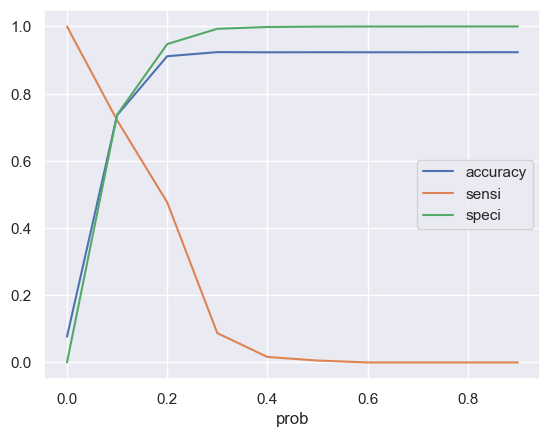

In [146]:
# Plotting it
cutoff_df.plot.line(x='prob', y=['accuracy','sensi','speci'])
plt.show()

In [147]:
# From the graph it is visible that the optimal cut off is at around 0.1

In [148]:
y_train_pred_sm_final['final_Predicted_Logistic_Reg'] = y_train_pred_sm_final.Churn_Prob.map( lambda x: 1 if x > 0.1 else 0)
y_train_pred_sm_final.head()

,Churn,Churn_Prob,Predicted_Logistic_Reg,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,final_Predicted_Logistic_Reg
0,0,0.254272,0,1,1,1,0,0,0,0,0,0,0,1
1,0,0.082928,0,1,0,0,0,0,0,0,0,0,0,0
2,0,0.105214,0,1,1,0,0,0,0,0,0,0,0,1
3,0,0.151791,0,1,1,0,0,0,0,0,0,0,0,1
4,0,0.012253,0,1,0,0,0,0,0,0,0,0,0,0


In [149]:
# Check the overall accuracy
metrics.accuracy_score(y_train_pred_sm_final.Churn, y_train_pred_sm_final.final_Predicted_Logistic_Reg)

0.7359106997005173

In [150]:
# Creating confusion matrix 
confusion2 = metrics.confusion_matrix(y_train_pred_sm_final.Churn, y_train_pred_sm_final.final_Predicted_Logistic_Reg )
confusion2

array([[12500,  4457],
       [  393,  1015]], dtype=int64)

In [151]:
# Substituting the value of true positive
TP = confusion2[1,1]
# Substituting the value of true negatives
TN = confusion2[0,0]
# Substituting the value of false positives
FP = confusion2[0,1] 
# Substituting the value of false negatives
FN = confusion2[1,0]

In [152]:
# Calculating the sensitivity
TP/(TP+FN)

0.7208806818181818

In [153]:
# Calculating the specificity
TN/(TN+FP)

0.7371586955239724

#### With the current cut off as 0.1 we have accuracy= 76%, sensitivity= 79% and specificity of around 77%

In [154]:
## Prediction on Test set

In [155]:
# Substituting all the columns in the final train model
col = X_train_log_rfe.columns

In [156]:
# Select the columns in X_train for X_test as well
X_test_sm = X_test[col]
X_test_sm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7871 entries, 10176 to 29798
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   onnet_mou_8        7871 non-null   float64
 1   total_og_mou_8     7871 non-null   float64
 2   total_rech_num_7   7871 non-null   int64  
 3   total_rech_data_7  7871 non-null   float64
 4   sachet_2g_6        7871 non-null   int64  
 5   sachet_2g_7        7871 non-null   int64  
 6   sep_vbc_3g         7871 non-null   float64
dtypes: float64(4), int64(3)
memory usage: 491.9 KB


In [157]:
# Add a constant to X_test
X_test_sm_con = sm.add_constant(X_test_sm[col])
X_test_sm_con.head()

,const,onnet_mou_8,total_og_mou_8,total_rech_num_7,total_rech_data_7,sachet_2g_6,sachet_2g_7,sep_vbc_3g
10176,1.0,168.19,665.66,6,1.0,0,0,0.00
4175,1.0,148.88,408.96,20,0.0,0,0,0.00
8664,1.0,302.19,819.61,17,0.0,0,0,0.00
25362,1.0,69.96,383.71,6,0.0,0,0,7.74
29681,1.0,34.81,669.88,38,11.0,1,11,0.00


In [158]:
# Storing prediction of test set in the variable 'y_test_pred'
y_test_pred_sm = res.predict(X_test_sm_con)


# Coverting it to df
y_test_pred_sm_df = pd.DataFrame(y_test_pred_sm)


# Converting y_test to dataframe
y_test_sm_df = pd.DataFrame(y_test)


# Remove index for both dataframes to append them side by side 
y_test_pred_sm_df.reset_index(drop=True, inplace=True)
y_test_sm_df.reset_index(drop=True, inplace=True)


# Append y_test_df and y_pred_df
y_pred_sm_final = pd.concat([y_test_sm_df, y_test_pred_sm_df],axis=1)


# Renaming column 
y_pred_sm_final= y_pred_sm_final.rename(columns = {0 : 'Churn_Prob'})
y_pred_sm_final.head()

,Churn,Churn_Prob
0,0,0.016083
1,0,0.106412
2,0,0.028273
3,0,0.019240
4,0,0.007139


In [159]:
# Making prediction using cut off 0.1

y_pred_sm_final['final_LogReg_predicted'] = y_pred_sm_final.Churn_Prob.map(lambda x: 1 if x > 0.1 else 0)
y_pred_sm_final.head()

,Churn,Churn_Prob,final_LogReg_predicted
0,0,0.016083,0
1,0,0.106412,1
2,0,0.028273,0
3,0,0.019240,0
4,0,0.007139,0


In [160]:
# Check the overall accuracy
metrics.accuracy_score(y_pred_sm_final['Churn'], y_pred_sm_final.final_LogReg_predicted)

0.7328166687841443

In [161]:
# Creating confusion matrix 
confusion2 = metrics.confusion_matrix(y_pred_sm_final['Churn'], y_pred_sm_final.final_LogReg_predicted )
confusion2

array([[5342, 1926],
       [ 177,  426]], dtype=int64)

In [162]:
# Substituting the value of true positive
TP = confusion2[1,1]
# Substituting the value of true negatives
TN = confusion2[0,0]
# Substituting the value of false positives
FP = confusion2[0,1] 
# Substituting the value of false negatives
FN = confusion2[1,0]

In [163]:
# Calculating the sensitivity
TP/(TP+FN)

0.7064676616915423

In [164]:
# Calculating the specificity
TN/(TN+FP)

0.7350027517886626

#### On Train Set, we got accuracy= 76%, sensitivity= 79% and specificity of around 77%

#### On Test Set, we got accuracy= 76%, sensitivity= 78% and specificity of around 76%

In [165]:
# Modeling Lib
from sklearn.decomposition import PCA
from sklearn.decomposition import IncrementalPCA

from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score

from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.pipeline import Pipeline
from sklearn.pipeline import FeatureUnion
from sklearn.model_selection import StratifiedKFold

### PCA

In [166]:
pca = PCA(random_state=42)
pca.fit_transform(scaled)

array([[-1.23724045e-01, -3.62283757e-01, -3.43809110e-02, ...,
         3.50834186e-15, -0.00000000e+00, -0.00000000e+00],
       [-1.93301945e-01,  1.74608158e-01,  3.99706744e-02, ...,
        -2.65531191e-17,  1.69102979e-15,  8.90565369e-16],
       [ 2.17992163e-01, -2.51715157e-02, -3.11500732e-01, ...,
        -3.86631875e-17,  2.64347215e-16, -8.87806349e-16],
       ...,
       [-3.40680458e-01,  8.80797635e-01,  6.99518499e-01, ...,
        -1.80876060e-18,  3.13696882e-17, -1.41342403e-17],
       [-2.59699707e-01,  4.26095936e-03, -1.86286919e-01, ...,
        -1.23664983e-18,  8.01150013e-18, -7.27965695e-20],
       [-4.44689268e-01, -3.00392884e-01, -2.69464732e-01, ...,
         1.55908241e-18,  8.95214602e-18, -5.67091566e-18]])

In [167]:
pca.components_

array([[-1.58078409e-19,  1.66533454e-16, -0.00000000e+00, ...,
         3.68058524e-03,  8.13732240e-04,  5.71484629e-03],
       [-5.12178665e-19,  5.55111512e-17,  1.11022302e-16, ...,
         9.52836091e-03,  1.08839077e-02,  1.48186187e-02],
       [-7.53707528e-20,  1.31838984e-16, -2.08166817e-17, ...,
         1.12045993e-02,  7.29727923e-03,  1.46556790e-02],
       ...,
       [ 9.99996585e-01, -2.36432413e-03, -6.53418633e-04, ...,
        -1.45243231e-04, -9.51640486e-05, -2.70786034e-04],
       [-0.00000000e+00,  3.98342153e-02, -3.49988720e-01, ...,
         4.13891305e-02, -2.54660519e-02,  2.10660649e-02],
       [-0.00000000e+00, -1.01904400e-01,  7.16484071e-01, ...,
        -8.33277744e-02,  7.56053896e-02, -1.09711570e-01]])

In [168]:
pca.explained_variance_ratio_

array([1.35195457e-01, 1.22182195e-01, 7.87943487e-02, 5.69694537e-02,
       4.16548800e-02, 3.43947351e-02, 2.92722602e-02, 2.89536272e-02,
       2.47391434e-02, 2.29235218e-02, 2.13665653e-02, 1.86595766e-02,
       1.71759792e-02, 1.60224846e-02, 1.42177423e-02, 1.36268197e-02,
       1.32103171e-02, 1.31704070e-02, 1.21308216e-02, 1.17901038e-02,
       1.07406587e-02, 9.97694861e-03, 9.47256696e-03, 8.99377509e-03,
       8.75114277e-03, 8.40076242e-03, 7.95145667e-03, 7.58805793e-03,
       7.41208685e-03, 7.05956809e-03, 6.69367317e-03, 6.53408770e-03,
       6.42287695e-03, 5.81477704e-03, 5.62930224e-03, 5.53923263e-03,
       5.44990457e-03, 5.08392242e-03, 4.94792538e-03, 4.83575101e-03,
       4.79783161e-03, 4.67709945e-03, 4.62527450e-03, 4.45961353e-03,
       4.42769426e-03, 4.24932242e-03, 4.11427706e-03, 4.00705873e-03,
       3.85028900e-03, 3.80885255e-03, 3.50098121e-03, 3.22981110e-03,
       3.09253733e-03, 2.93742976e-03, 2.86843451e-03, 2.82427905e-03,
      

In [169]:
var_cumu = np.cumsum(pca.explained_variance_ratio_)
var_cumu

array([0.13519546, 0.25737765, 0.336172  , 0.39314145, 0.43479633,
       0.46919107, 0.49846333, 0.52741696, 0.5521561 , 0.57507962,
       0.59644619, 0.61510576, 0.63228174, 0.64830423, 0.66252197,
       0.67614879, 0.68935911, 0.70252951, 0.71466034, 0.72645044,
       0.7371911 , 0.74716805, 0.75664061, 0.76563439, 0.77438553,
       0.78278629, 0.79073775, 0.79832581, 0.8057379 , 0.81279746,
       0.81949114, 0.82602522, 0.8324481 , 0.83826288, 0.84389218,
       0.84943141, 0.85488132, 0.85996524, 0.86491317, 0.86974892,
       0.87454675, 0.87922385, 0.88384912, 0.88830874, 0.89273643,
       0.89698575, 0.90110003, 0.90510709, 0.90895738, 0.91276623,
       0.91626721, 0.91949702, 0.92258956, 0.92552699, 0.92839542,
       0.9312197 , 0.93403132, 0.9366539 , 0.93919067, 0.9416668 ,
       0.94405119, 0.94637483, 0.9485468 , 0.95060999, 0.95260086,
       0.95453425, 0.95643978, 0.95825213, 0.9599695 , 0.96167544,
       0.96334711, 0.96500666, 0.96662098, 0.96820663, 0.96977

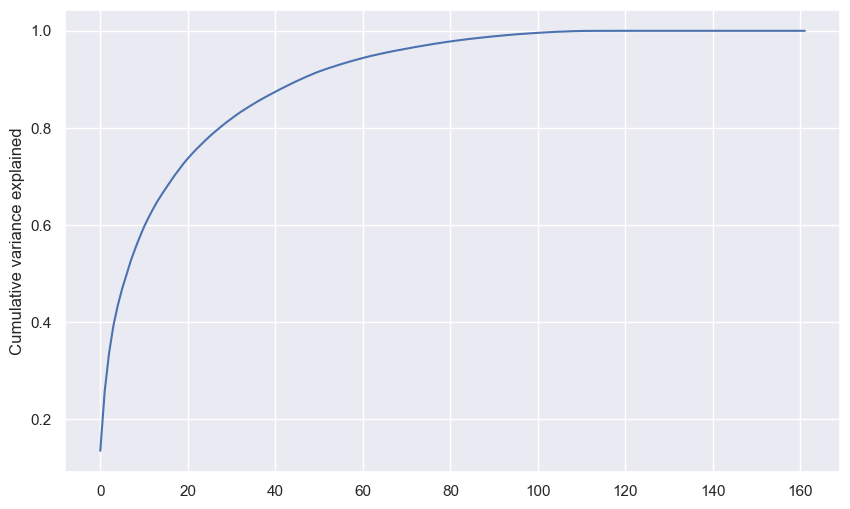

In [170]:
fig = plt.figure(figsize=[10,6])
plt.plot(var_cumu)
plt.ylabel('Cumulative variance explained')
plt.show()

In [171]:
pca_final = IncrementalPCA(n_components=65)

In [172]:
df_train_pca = pca_final.fit_transform(X_train)

In [173]:
df_train_pca.shape

(18365, 65)

In [174]:
# Performing PCA on test dataset

df_test_pca = pca_final.transform(X_test)
df_test_pca.shape

(7871, 65)

#### PCA Logistic Regression

In [175]:
# fitting the model using Logistic Regression

learner_pca = LogisticRegression()
model_pca = learner_pca.fit(df_train_pca, y_train)

In [176]:
# predicting on test dataset
y_pred = model_pca.predict(df_test_pca)

In [177]:
# checking the auc score
y_pred_prob = model_pca.predict_proba(df_test_pca)[:, 1]
metrics.roc_auc_score(y_test,y_pred_prob)

0.854435171418636

In [178]:
# printing the confusion matrix
confusion_matrix_lr_pca = confusion_matrix(y_test, y_pred)
print(confusion_matrix_lr_pca)

[[4521 2747]
 [  73  530]]


In [179]:
# Substituting the value of true positive
TP = confusion_matrix_lr_pca[1,1]
# Substituting the value of true negatives
TN = confusion_matrix_lr_pca[0,0]
# Substituting the value of false positives
FP = confusion_matrix_lr_pca[0,1] 
# Substituting the value of false negatives
FN = confusion_matrix_lr_pca[1,0]

In [180]:
# Calculating the sensitivity
TP/(TP+FN)

0.87893864013267

In [181]:
# Calculating the specificity
TN/(TN+FP)

0.622041827187672

#### Hyperparameter Tuning for PCA Logistic Regression

In [182]:
# Checking the class imbalance
y_train.value_counts()/y_train.shape

Churn
0    0.923332
1    0.076668
Name: count, dtype: float64

In [183]:
# PCA
pca = PCA()

# logistic regression - the class weight is used to handle class imbalance - it adjusts the cost function
logistic = LogisticRegression(class_weight={0:0.1, 1: 0.9})

# create pipeline
steps = [("scaler", MinMaxScaler()), 
         ("pca", pca),
         ("logistic", logistic)
        ]

# compile pipeline
pca_logistic = Pipeline(steps)

# hyperparameter space
params = {'pca__n_components': [60, 80], 'logistic__C': [0.1, 0.5, 1, 2, 3, 4, 5, 10], 'logistic__penalty': ['l1', 'l2']}

# create 5 folds
folds = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 4)

# create gridsearch object
model = GridSearchCV(estimator=pca_logistic, cv=folds, param_grid=params, scoring='roc_auc', n_jobs=-1, verbose=1)

In [184]:
# fit model
model.fit(df_train_pca, y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=4, shuffle=True),
             estimator=Pipeline(steps=[('scaler', MinMaxScaler()),
                                       ('pca', PCA()),
                                       ('logistic',
                                        LogisticRegression(class_weight={0: 0.1,
                                                                         1: 0.9}))]),
             n_jobs=-1,
             param_grid={'logistic__C': [0.1, 0.5, 1, 2, 3, 4, 5, 10],
                         'logistic__penalty': ['l1', 'l2'],
                         'pca__n_components': [60, 80]},
             scoring='roc_auc', verbose=1)

In [185]:
# print best hyperparameters

print("Best AUC: ", model.best_score_)
print("Best hyperparameters: ", model.best_params_)

Best AUC:  0.8922519777455159
Best hyperparameters:  {'logistic__C': 10, 'logistic__penalty': 'l2', 'pca__n_components': 60}


In [186]:
# predict churn on test data
y_pred = model_pca.predict(df_test_pca)

# create onfusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

# check area under curve
y_pred_prob = model.predict_proba(df_test_pca)[:, 1]
print("AUC:", round(roc_auc_score(y_test, y_pred_prob),2))

[[4521 2747]
 [  73  530]]
AUC: 0.89


In [187]:
# Substituting the value of true positive
TP = cm[1,1]
# Substituting the value of true negatives
TN = cm[0,0]
# Substituting the value of false positives
FP = cm[0,1] 
# Substituting the value of false negatives
FN = cm[1,0]

# Calculating the sensitivity
print("Sensitivity:", TP/(TP+FN))

# Calculating the specificity
print("Specificity:", TN/(TN+FP))

Sensitivity: 0.87893864013267
Specificity: 0.622041827187672


#### AUC score of Hyperparameter Tuning for Logistic Regression with PCA is 89%

### Decision Tree with PCA

In [188]:
from sklearn.tree import DecisionTreeClassifier
from IPython.display import Image  
from six import StringIO  
from sklearn.tree import export_graphviz


from sklearn.model_selection import GridSearchCV

In [189]:
dt = DecisionTreeClassifier(random_state=42)

In [190]:
# Defining the parameters

params = {
    'max_depth': [2, 3, 5, 10, 20],
    'min_samples_leaf': [5, 10, 20, 50, 100],
    'min_samples_split': [50, 150, 50]
}

In [191]:
# Instantiate the grid search model
grid_search = GridSearchCV(estimator=dt, 
                           param_grid=params, 
                           cv=4, n_jobs=-1, verbose=1, scoring = "accuracy")

In [192]:
grid_search.fit(df_train_pca, y_train)

Fitting 4 folds for each of 75 candidates, totalling 300 fits


GridSearchCV(cv=4, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [2, 3, 5, 10, 20],
                         'min_samples_leaf': [5, 10, 20, 50, 100],
                         'min_samples_split': [50, 150, 50]},
             scoring='accuracy', verbose=1)

In [193]:
score_df = pd.DataFrame(grid_search.cv_results_)
score_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score
0,0.875164,0.015883,0.007469,0.002265,2,5,50,"{'max_depth': 2, 'min_samples_leaf': 5, 'min_samples_split': 50}",0.930096,0.932912,0.933348,0.931387,0.931936,0.001288,13
1,0.882016,0.031582,0.006113,0.000987,2,5,150,"{'max_depth': 2, 'min_samples_leaf': 5, 'min_samples_split': 150}",0.930096,0.932912,0.933348,0.931387,0.931936,0.001288,13
2,0.867233,0.024115,0.007440,0.000956,2,5,50,"{'max_depth': 2, 'min_samples_leaf': 5, 'min_samples_split': 50}",0.930096,0.932912,0.933348,0.931387,0.931936,0.001288,13
3,0.865431,0.026300,0.007545,0.000875,2,10,50,"{'max_depth': 2, 'min_samples_leaf': 10, 'min_samples_split': 50}",0.930096,0.932912,0.933348,0.931387,0.931936,0.001288,13
4,0.999899,0.108266,0.007632,0.000855,2,10,150,"{'max_depth': 2, 'min_samples_leaf': 10, 'min_samples_split': 150}",0.930096,0.932912,0.933348,0.931387,0.931936,0.001288,13


In [194]:
score_df.nlargest(5,"mean_test_score")

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score
15,1.406193,0.081302,0.006462,0.000425,3,5,50,"{'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 50}",0.930096,0.936615,0.935308,0.932694,0.933678,0.002504,1
16,1.465702,0.070879,0.006766,0.000738,3,5,150,"{'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 150}",0.930096,0.936615,0.935308,0.932694,0.933678,0.002504,1
17,1.423171,0.059391,0.007145,0.000701,3,5,50,"{'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 50}",0.930096,0.936615,0.935308,0.932694,0.933678,0.002504,1
18,1.332761,0.018776,0.007272,0.001552,3,10,50,"{'max_depth': 3, 'min_samples_leaf': 10, 'min_samples_split': 50}",0.930096,0.936615,0.935308,0.932694,0.933678,0.002504,1
19,1.343093,0.034269,0.007205,0.000888,3,10,150,"{'max_depth': 3, 'min_samples_leaf': 10, 'min_samples_split': 150}",0.930096,0.936615,0.935308,0.932694,0.933678,0.002504,1


In [195]:
grid_search.best_estimator_

DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, min_samples_split=50,
                       random_state=42)

In [196]:
dt_best = DecisionTreeClassifier( random_state = 42,
                                  max_depth=3, 
                                  min_samples_leaf=5,
                                  min_samples_split=50)

In [197]:
dt_best.fit(df_train_pca, y_train)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, min_samples_split=50,
                       random_state=42)

In [198]:
confusion_matrix_dt = confusion_matrix(y_test, dt_best.predict(df_test_pca))
confusion_matrix_dt

array([[7211,   57],
       [ 467,  136]], dtype=int64)

In [199]:
# check area under curve

y_pred_prob = dt_best.predict_proba(df_test_pca)[:, 1]
print("AUC:", round(roc_auc_score(y_test, y_pred_prob),2))

AUC: 0.78


In [200]:
# Substituting the value of true positive
TP = confusion_matrix_dt[1,1]
# Substituting the value of true negatives
TN = confusion_matrix_dt[0,0]
# Substituting the value of false positives
FP = confusion_matrix_dt[0,1] 
# Substituting the value of false negatives
FN = confusion_matrix_dt[1,0]

# Calculating the sensitivity
print("Sensitivity:", TP/(TP+FN))

# Calculating the specificity
print("Specificity:", TN/(TN+FP))

Sensitivity: 0.22553897180762852
Specificity: 0.9921574023115025


#### Using Decision Tree we got AUC of 78%, Specificity of 99%, but Sensitivity still remains low.

### AUC score of Decision Tree with PCA is 78%

### Random Forest

In [201]:
# random forest - the class weight is used to handle class imbalance - it adjusts the cost function
Random_forest = RandomForestClassifier(class_weight={0:0.1, 1: 0.9}, n_jobs = -1)

# hyperparameter space
params = {"criterion": ['gini', 'entropy'], "max_features": ['auto', 0.4]}

# create 5 folds
k_folds = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 4)

# create gridsearch object
model = GridSearchCV(estimator=Random_forest, cv=folds, param_grid=params, scoring='roc_auc', n_jobs=-1, verbose=1)

In [202]:
# fit model
model.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=4, shuffle=True),
             estimator=RandomForestClassifier(class_weight={0: 0.1, 1: 0.9},
                                              n_jobs=-1),
             n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_features': ['auto', 0.4]},
             scoring='roc_auc', verbose=1)

In [203]:
# print best hyperparameters
model.best_score_ # Checking Best score
model.best_params_ # Checking the best parameters

{'criterion': 'entropy', 'max_features': 0.4}

In [204]:
# predict churn on test data
y_pred = model.predict(X_test)

# create confusion matrix
confusion_matrix_rf = confusion_matrix(y_test, y_pred)
confusion_matrix_rf

array([[7156,  112],
       [ 311,  292]], dtype=int64)

In [205]:
# check area under curve
y_pred_prob = model.predict_proba(X_test)[:, 1]
round(roc_auc_score(y_test, y_pred_prob),2)

0.93

In [206]:
# Substituting the value of true positive
TP = confusion_matrix_rf[1,1]
# Substituting the value of true negatives
TN = confusion_matrix_rf[0,0]
# Substituting the value of false positives
FP = confusion_matrix_rf[0,1] 
# Substituting the value of false negatives
FN = confusion_matrix_rf[1,0]

# Calculating the sensitivity
print("Sensitivity:", TP/(TP+FN))

# Calculating the specificity
print("Specificity:", TN/(TN+FP))

Sensitivity: 0.4842454394693201
Specificity: 0.9845899834892681


In [207]:
## The AUC= 93% and Specificity= 98% is high but Sensitivity is very low
# let us improve the score by finding the best features

In [208]:
# Re-running the randomforest on the X_train

max_features = int(round(np.sqrt(X_train.shape[1])))    
print(max_features)

rf_model = RandomForestClassifier(n_estimators=100, max_features=max_features, 
                                  class_weight={0:0.1, 1: 0.9}, oob_score=True, random_state=4, verbose=1)

13


In [209]:
# fit model
rf_model.fit(X_train, y_train)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   14.5s


RandomForestClassifier(class_weight={0: 0.1, 1: 0.9}, max_features=13,
                       oob_score=True, random_state=4, verbose=1)

In [210]:
rf_model.oob_score_

0.9445140212360468

In [211]:
# predict churn on test data
y_pred = rf_model.predict(X_test)

# create confusion matrix
confusion_matrix_rf1 = confusion_matrix(y_test, y_pred)
print(confusion_matrix_rf1)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s


[[7177   91]
 [ 341  262]]


In [212]:
# check area under curve

y_pred_prob = rf_model.predict_proba(X_test)[:, 1]
round(roc_auc_score(y_test, y_pred_prob),2)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s


0.93

In [213]:
# Substituting the value of true positive
TP = confusion_matrix_rf1[1,1]
# Substituting the value of true negatives
TN = confusion_matrix_rf1[0,0]
# Substituting the value of false positives
FP = confusion_matrix_rf1[0,1] 
# Substituting the value of false negatives
FN = confusion_matrix_rf1[1,0]

# Calculating the sensitivity
print("Sensitivity:", TP/(TP+FN))

# Calculating the specificity
print("Specificity:", TN/(TN+FP))

Sensitivity: 0.43449419568822556
Specificity: 0.9874793615850302


### AUC score using Random Forest is 92%

### AUC score of Hyperparameter Tuning for Logistic Regression with PCA is 89%
### AUC score of Decision Tree with PCA is 78%
### AUC score using Random Forest is 92%


## Hence Random Forest is the best model for this case, having a AUC of 92%

#### The important features based on Logistic Regression are

In [214]:
X_test_sm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7871 entries, 10176 to 29798
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   onnet_mou_8        7871 non-null   float64
 1   total_og_mou_8     7871 non-null   float64
 2   total_rech_num_7   7871 non-null   int64  
 3   total_rech_data_7  7871 non-null   float64
 4   sachet_2g_6        7871 non-null   int64  
 5   sachet_2g_7        7871 non-null   int64  
 6   sep_vbc_3g         7871 non-null   float64
dtypes: float64(4), int64(3)
memory usage: 491.9 KB


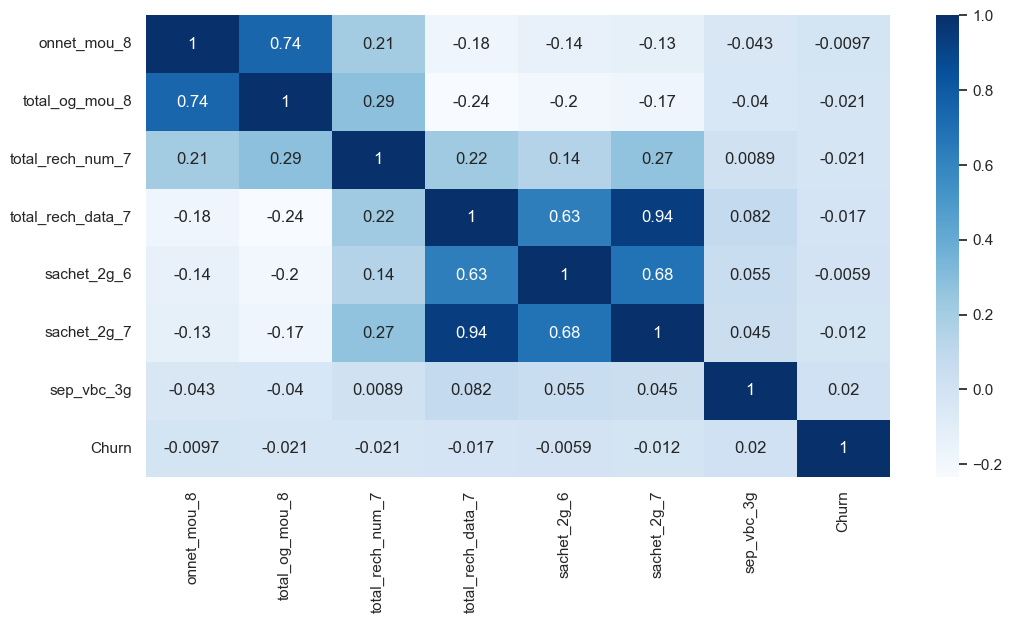

In [215]:
# plotting feature correlation with Churn

plt.figure(figsize=[12,6])
data = pd.concat([X_test_sm, y_test_sm_df],axis=1)
sns.heatmap(data.corr(), cmap='Blues', annot = True)
plt.show()

# Recommendations

### Business Insights


- Less number of **high value customer** are churing but for last **6 month** no new high valued cusotmer is onboarded which is concerning and company should concentrate on that aspect.

- Customers with less than 4 years of tenure are more likely to churn and company should concentrate more on that segment by rolling out new schems to that group.

- Average revenue per user seems to be most important feature in determining churn prediction.

- Incoming and Outgoing Calls on romaing for 8th month are strong indicators of churn behaviour

- Local Outgoing calls made to landline , fixedline , mobile and call center provides a strong indicator of churn behaviour.

- Better 2G/3G area coverage where 2G/3G services are not good, it's strong indicator of churn behaviour.


### Model Insights


- As per our analysis Random forest produce best accuracy and models can be selected to predict churn data for future dataset or production.

In [216]:
y_pred_proba = model.predict_proba(X_test)[:,1]

In [217]:
import pandas as pd

scm_df = X_test.copy()
scm_df['churn_prob'] = y_pred_proba

In [218]:
def risk_segment(p):
    if p >= 0.7:
        return "High Risk"
    elif p >= 0.3:
        return "Medium Risk"
    else:
        return "Low Risk"

scm_df['risk_segment'] = scm_df['churn_prob'].apply(risk_segment)

In [219]:
scm_df['value_segment'] = scm_df['total_rech_amt_7'].apply(
    lambda x: "High Value" if x > 478 else "Low Value"
)

In [220]:
def assign_priority(row):
    if row['risk_segment'] == "High Risk" and row['value_segment'] == "High Value":
        return "Immediate Action"
    elif row['risk_segment'] == "High Risk":
        return "Targeted Action"
    else:
        return "No Action"

scm_df['priority'] = scm_df.apply(assign_priority, axis=1)

In [221]:
def retention_strategy(priority):
    if priority == "Immediate Action":
        return "High Discount + Call Support"
    elif priority == "Targeted Action":
        return "Moderate Offer"
    else:
        return "No Offer"

scm_df['strategy'] = scm_df['priority'].apply(retention_strategy)

In [222]:
print("Customer Distribution by Priority:")
print(scm_df['priority'].value_counts())

print("\nStrategy Distribution:")
print(scm_df['strategy'].value_counts())

Customer Distribution by Priority:
priority
No Action           7641
Targeted Action      162
Immediate Action      68
Name: count, dtype: int64

Strategy Distribution:
strategy
No Offer                        7641
Moderate Offer                   162
High Discount + Call Support      68
Name: count, dtype: int64


In [223]:
scm_df['revenue'] = scm_df['total_rech_amt_7']

scm_df['revenue_at_risk'] = scm_df['churn_prob'] * scm_df['revenue']

In [224]:
print("Top Customers at Risk:")
print(scm_df[['churn_prob','revenue','revenue_at_risk']].sort_values(by='revenue_at_risk', ascending=False).head(10))

Top Customers at Risk:
       churn_prob  revenue  revenue_at_risk
17056        0.50     3500          1750.00
16686        0.86     1479          1271.94
23412        0.95     1280          1216.00
10190        0.81     1284          1040.04
7199         0.72     1440          1036.80
19980        0.82     1252          1026.64
8295         0.91     1100          1001.00
20699        0.88     1120           985.60
7530         0.87     1100           957.00
29383        0.57     1600           912.00


In [225]:
# Assume total retention budget
budget = 50000

# Cost per intervention
cost_map = {
    "Immediate Action": 500,
    "Targeted Action": 200,
    "No Action": 0
}

scm_df['cost'] = scm_df['priority'].map(cost_map)

# Sort by importance (highest revenue at risk first)
scm_df = scm_df.sort_values(by='revenue_at_risk', ascending=False)

# Allocate budget
scm_df['allocated'] = (scm_df['cost'].cumsum() <= budget)

In [226]:
total_revenue = scm_df['revenue'].sum()
total_risk = scm_df['revenue_at_risk'].sum()

print("Total Revenue:", total_revenue)
print("Potential Revenue Loss:", total_risk)

Total Revenue: 4815633
Potential Revenue Loss: 319622.32999999996


In [227]:
pd.crosstab(scm_df['risk_segment'], scm_df['value_segment'])

value_segment,High Value,Low Value
risk_segment,,
High Risk,68,162
Low Risk,4339,2897
Medium Risk,256,149
